In [ ]:
import os
import numpy as np
import pandas as pd
import torch 
from torch import nn
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

import models
from reader import Pdyn_ExtractDataset

: 

In [ ]:
%load_ext autoreload
%autoreload 2

: 

# read data

In [4]:
pt_path = 'dataExample.pt'

train_DS = Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=300, n_repeat=10)
val_DS= Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=600, n_repeat=1)

train_iter = iter(DataLoader(train_DS, batch_size=1, num_workers=4))

# val_DL = DataLoader(val_DS, batch_size=1, num_workers=4)

# load model

In [99]:
ckpt = torch.load(ckpt_path)

In [8]:
model = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


In [9]:
model.u

MLP_surrogate(
  (u_theta): Sequential(
    (Linear_0): Linear(in_features=2, out_features=32, bias=True)
    (Tanh_0): Tanh()
    (Linear_1): Linear(in_features=32, out_features=32, bias=True)
    (Tanh_1): Tanh()
    (Linear_2): Linear(in_features=32, out_features=32, bias=True)
    (Tanh_2): Tanh()
    (Linear_3): Linear(in_features=32, out_features=1, bias=True)
  )
)

# make prediction

In [134]:
# get data
data_batch = next(train_iter)

def predict_and_vis(model, data_batch, train_DS):
    s_col, t_col, s_all, t_b, u_b, Mean, Var = model.get_data(data_batch, False)

    grid_s = np.linspace(0,1,s_all.shape[1])

    # predict
    u_pred_b = model.u(s_all, t_b)

    u_pred_b = u_pred_b.detach().numpy()
    u_b = u_b.detach().numpy()[0]
    N_theta = 0.5*(u_pred_b[:,1:]+u_pred_b[:,:-1]).sum(axis=1)
    Mean = Mean.detach().numpy().flatten()
    Var = Var.detach().numpy().flatten()

    pl.behavior_curves(model);

    pl.density_by_time(u_b, u_pred_b, train_DS);
    
    print(N_theta)
    print(Mean)

In [ ]:
from matplotlib import pyplot as plt

In [107]:
softmax_pred = torch.softmax(u_pred_b, axis=1)

# version 3 : original 

[ 9.555349 10.571448 11.133445 11.540087 12.098855 12.674509]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


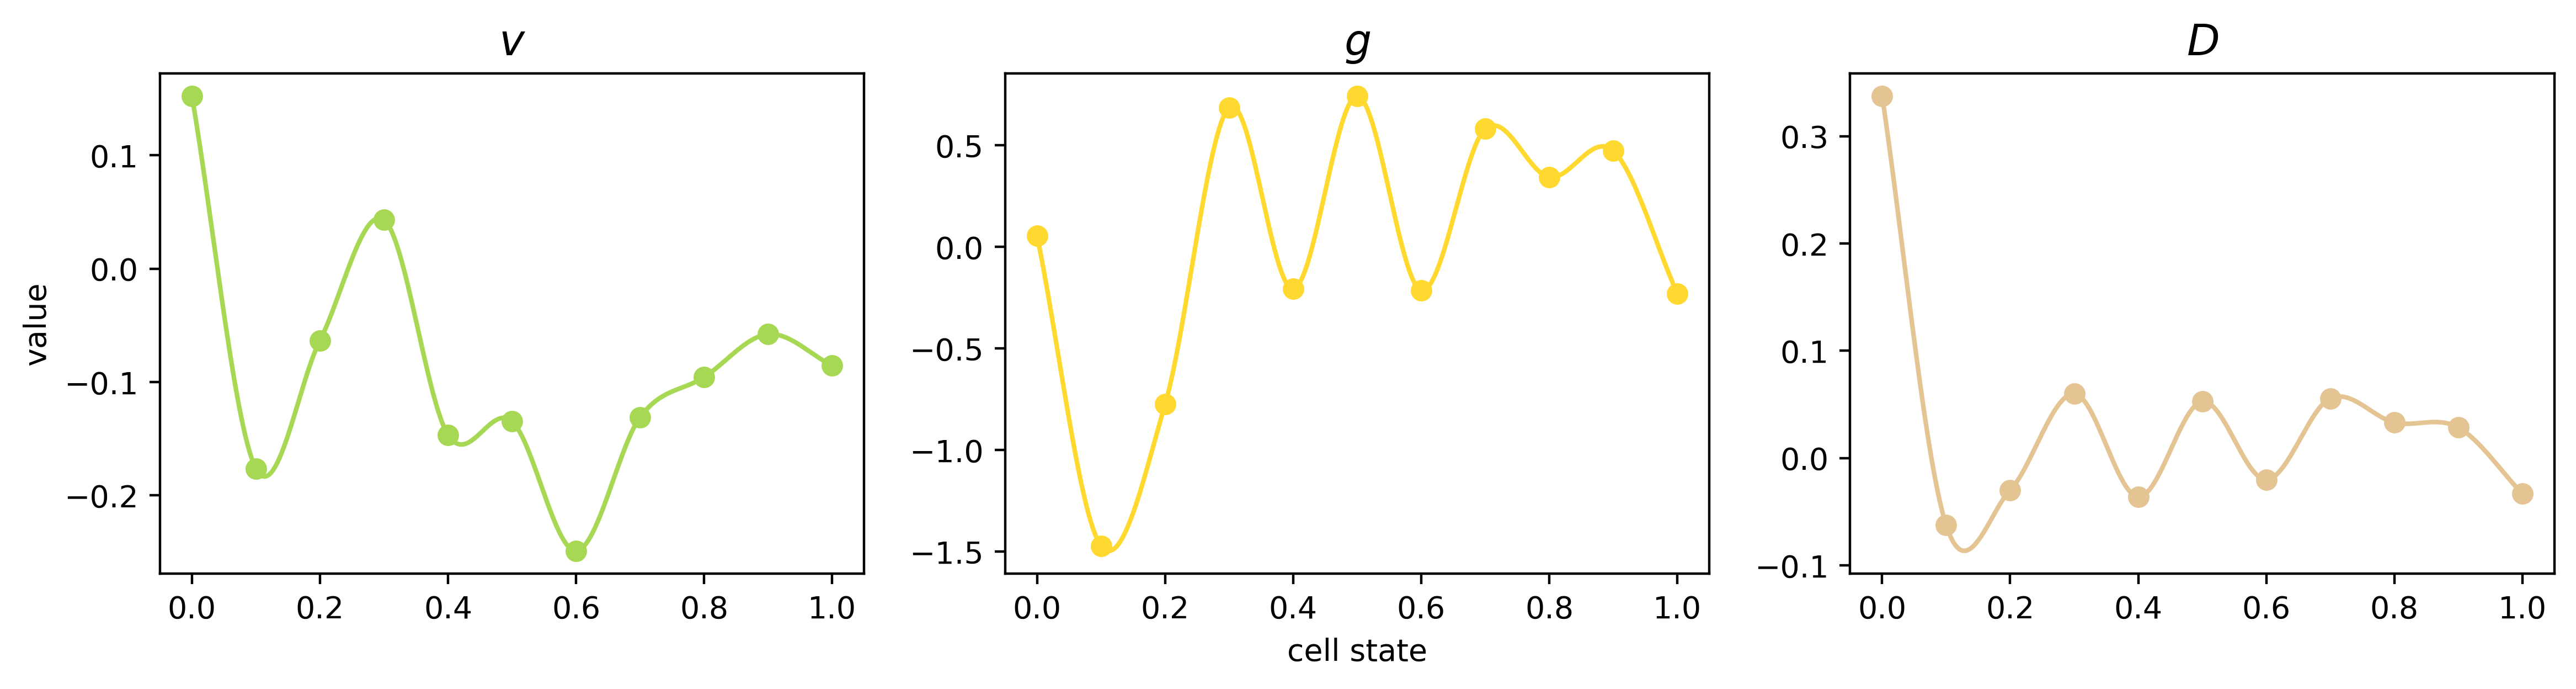

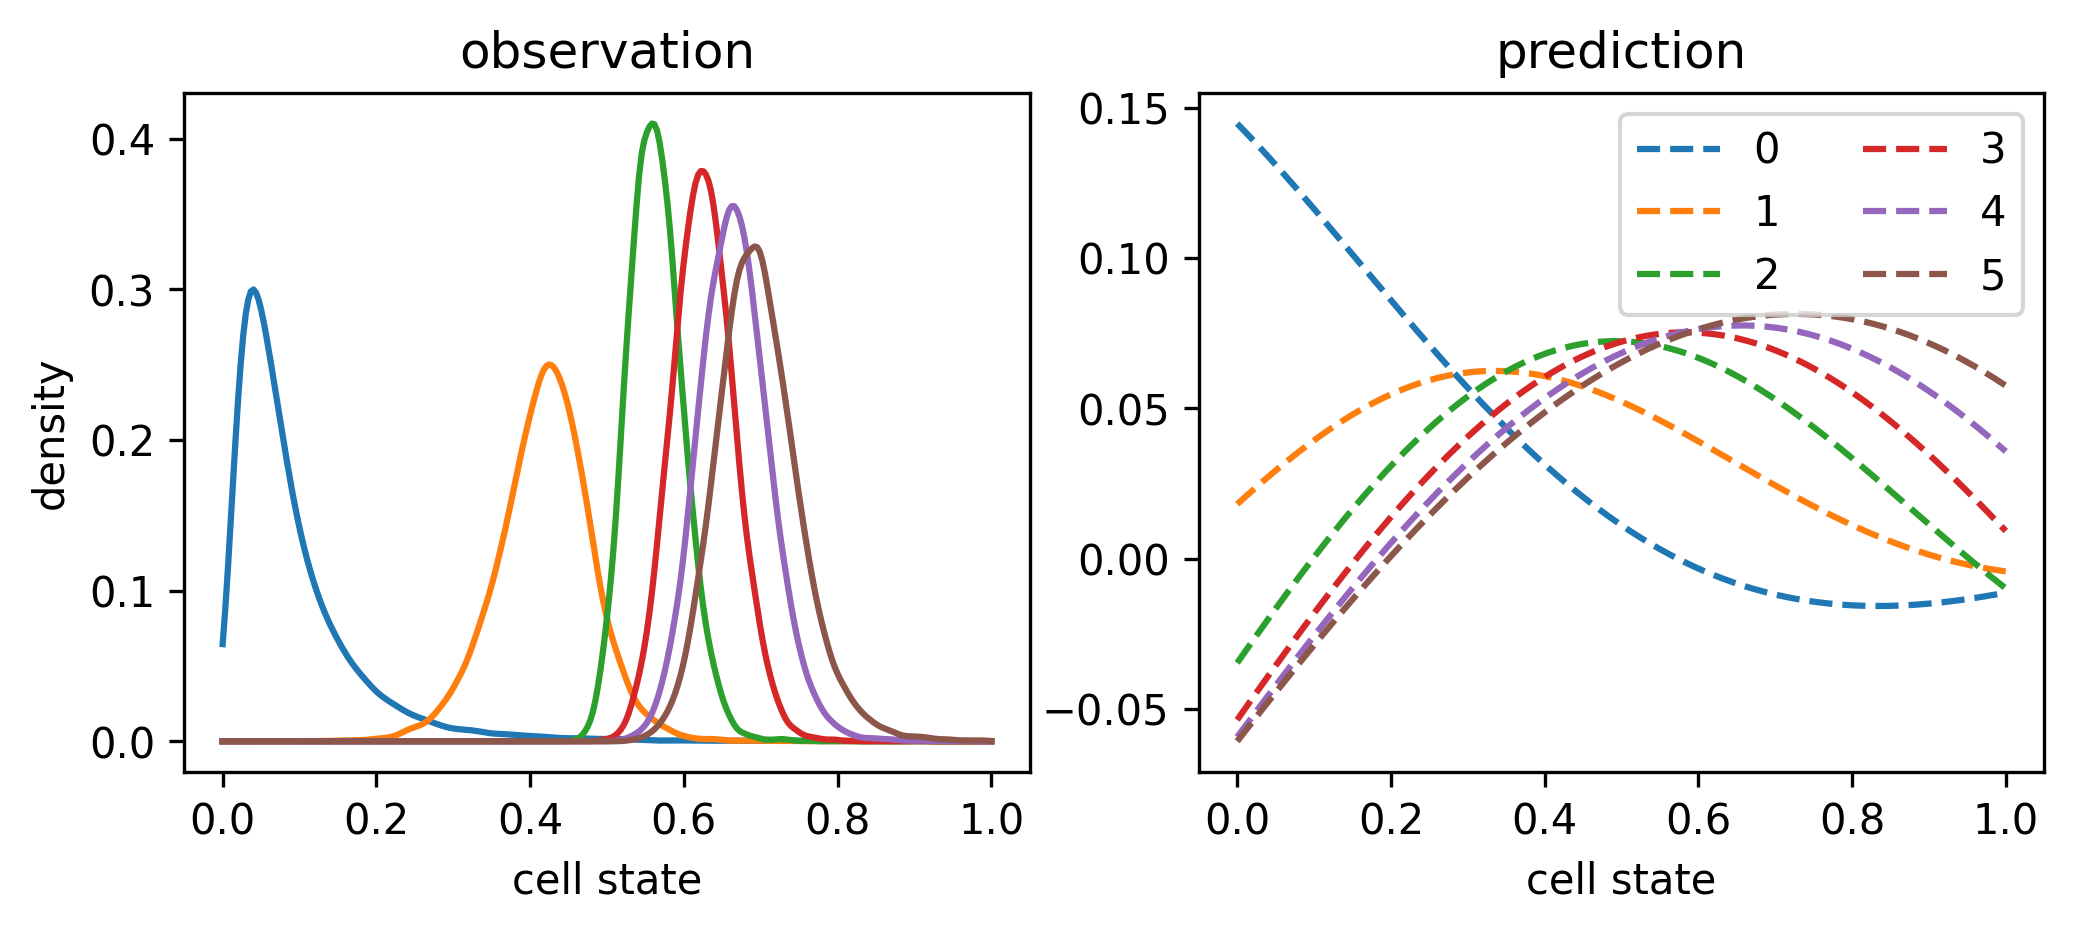

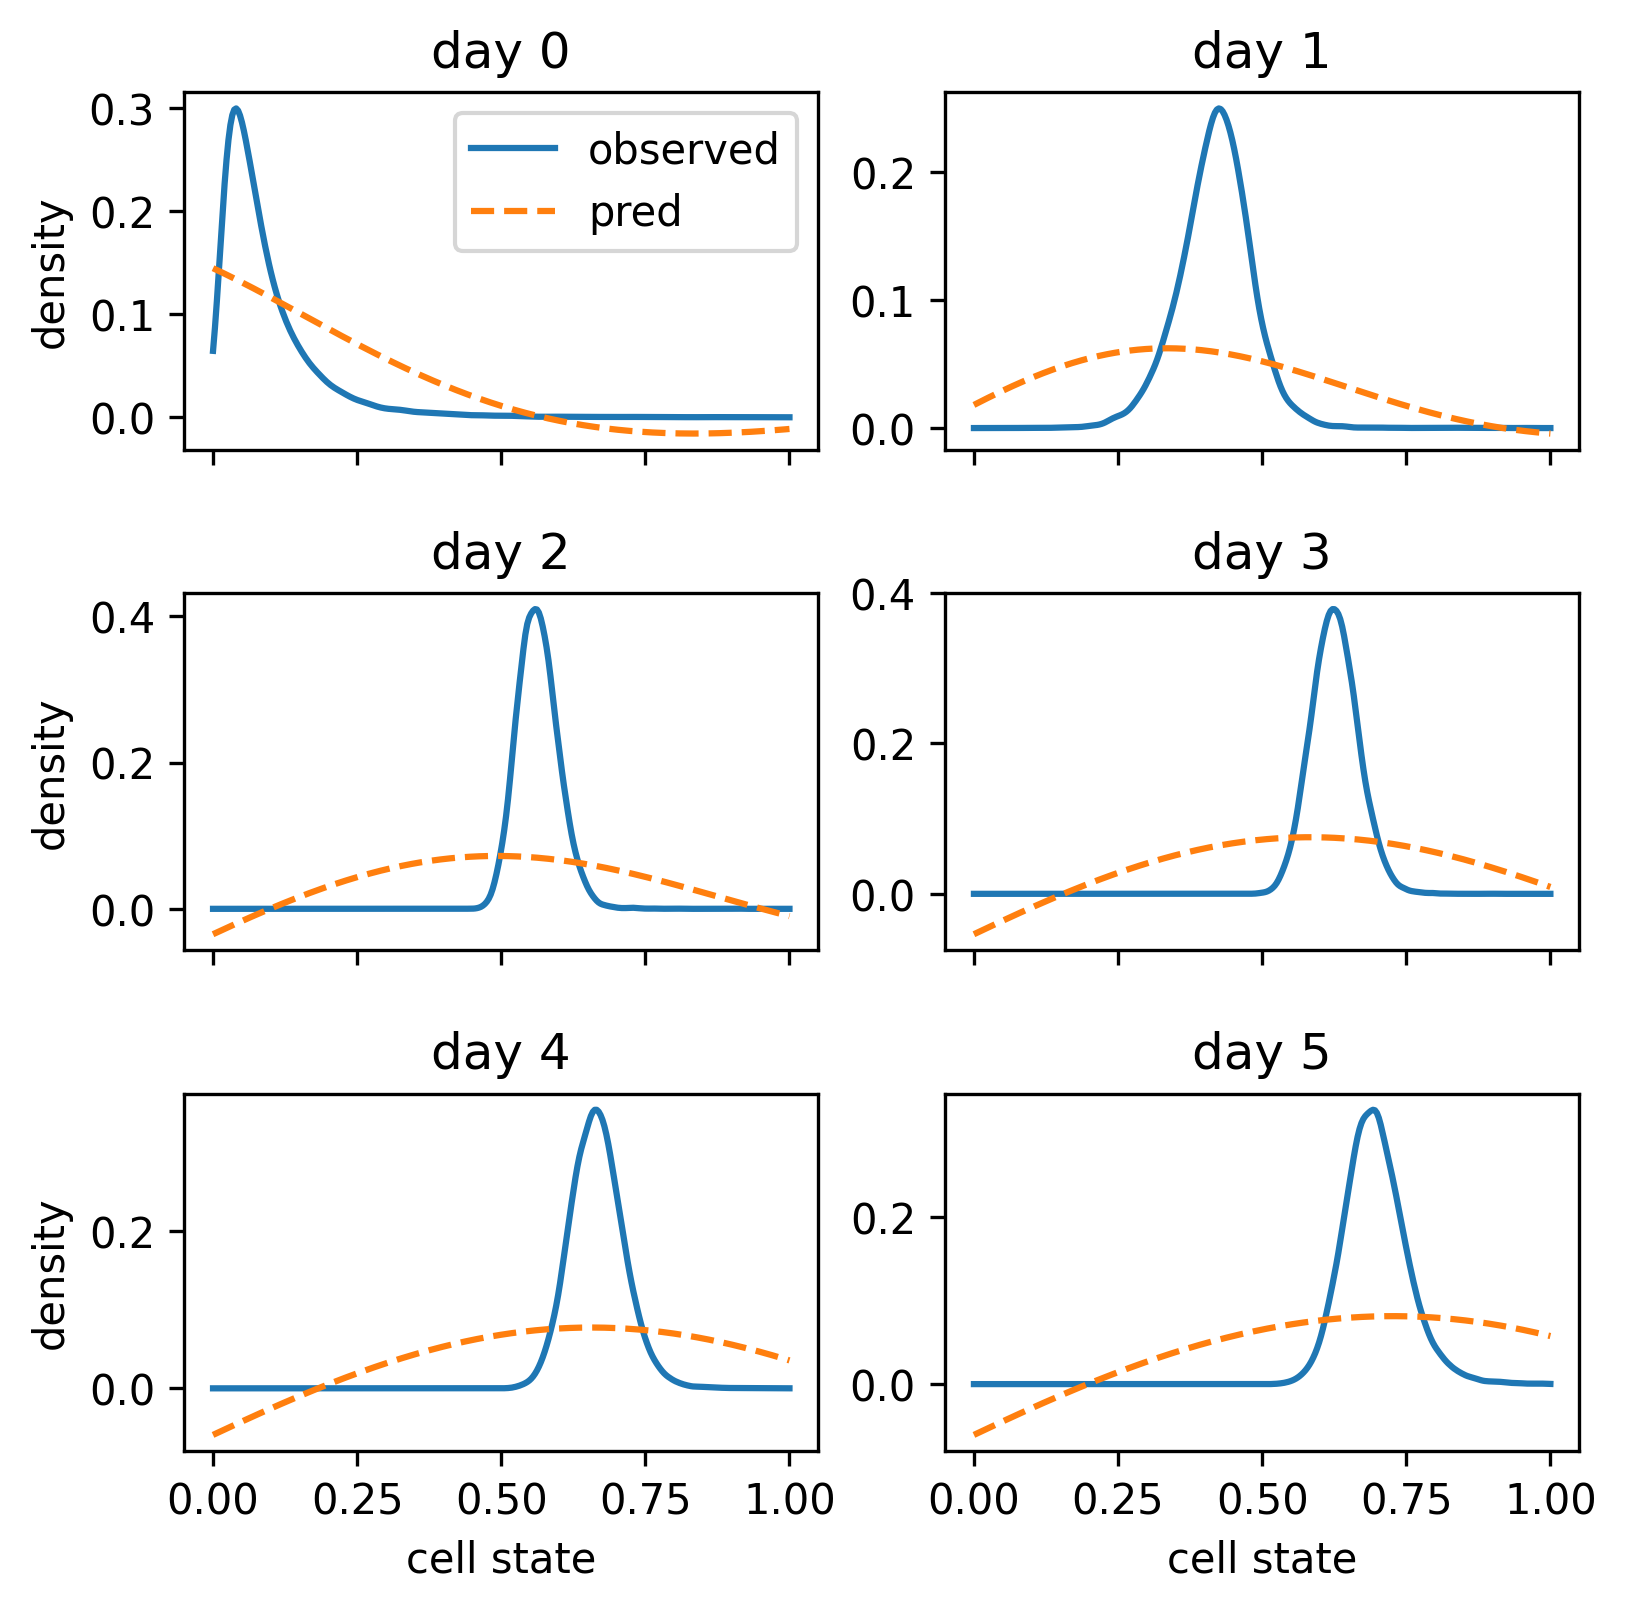

In [142]:
ckpt_path = "../logs/Cspline_PINN/lightning_logs/version_3/checkpoints/epoch=297-total_loss=10.55338860.ckpt"
kld_m = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

predict_and_vis(kld_m, data_batch, train_DS)

# version 7

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


[11.364319  10.7483425 11.700367  12.519925  12.688885  12.60162  ]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


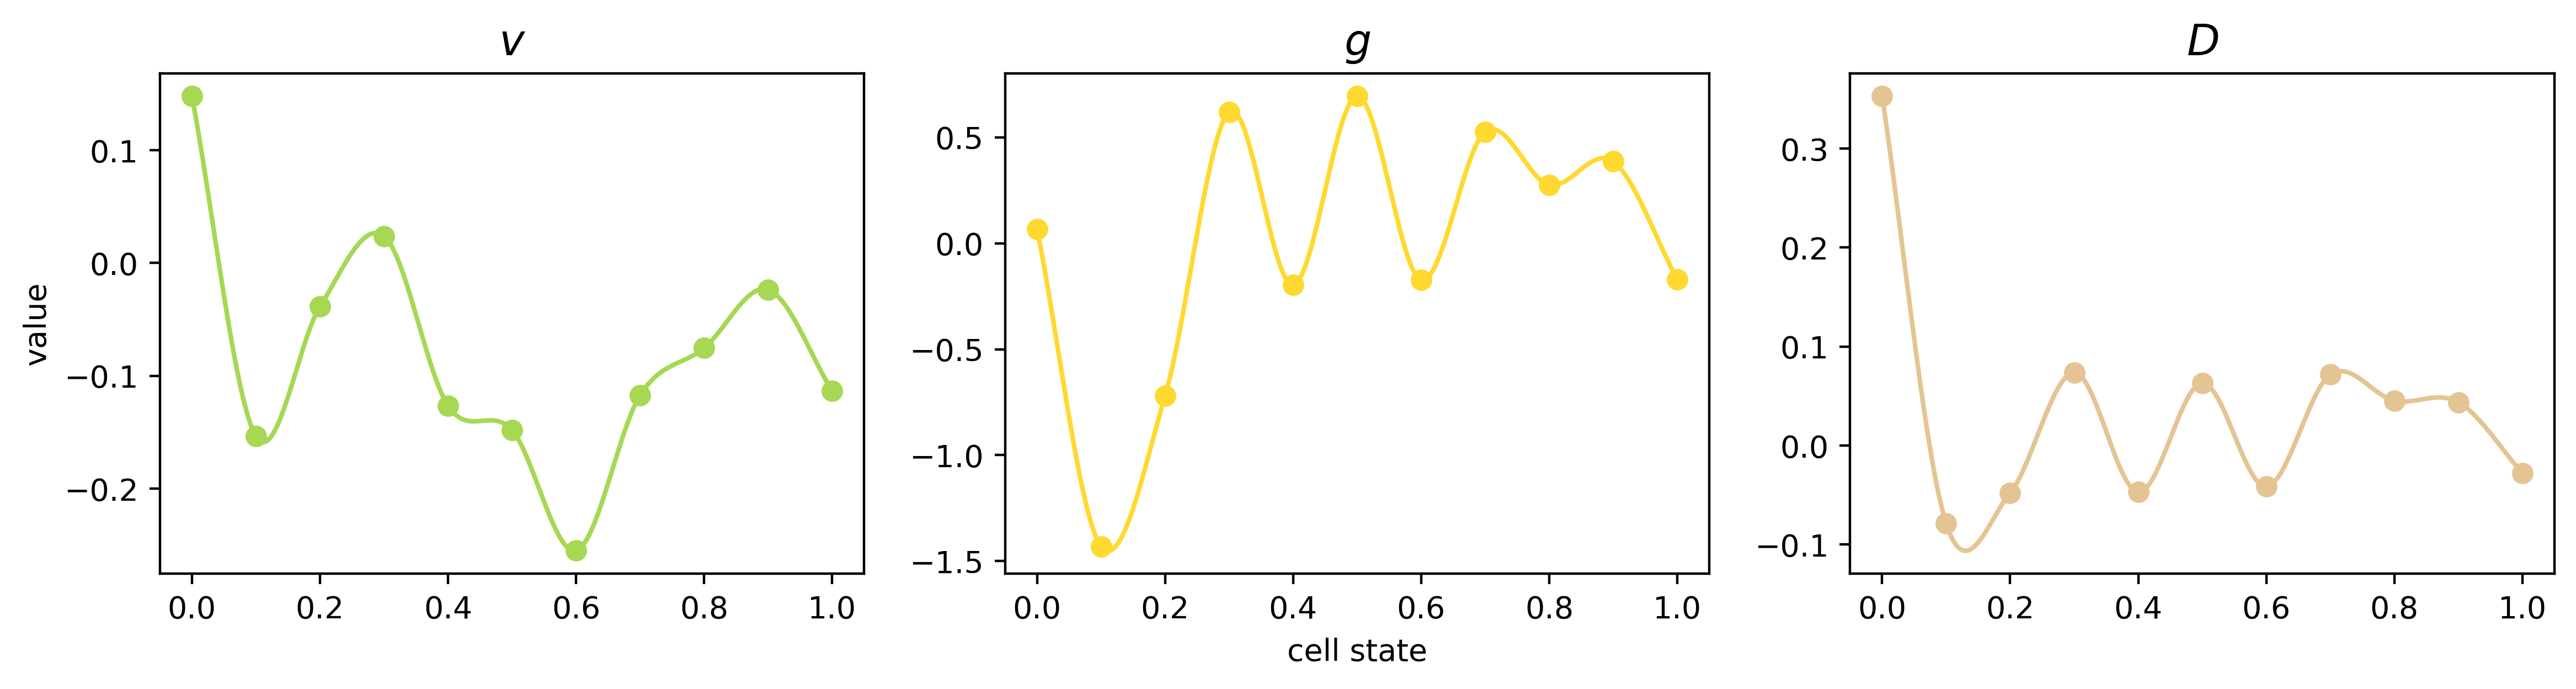

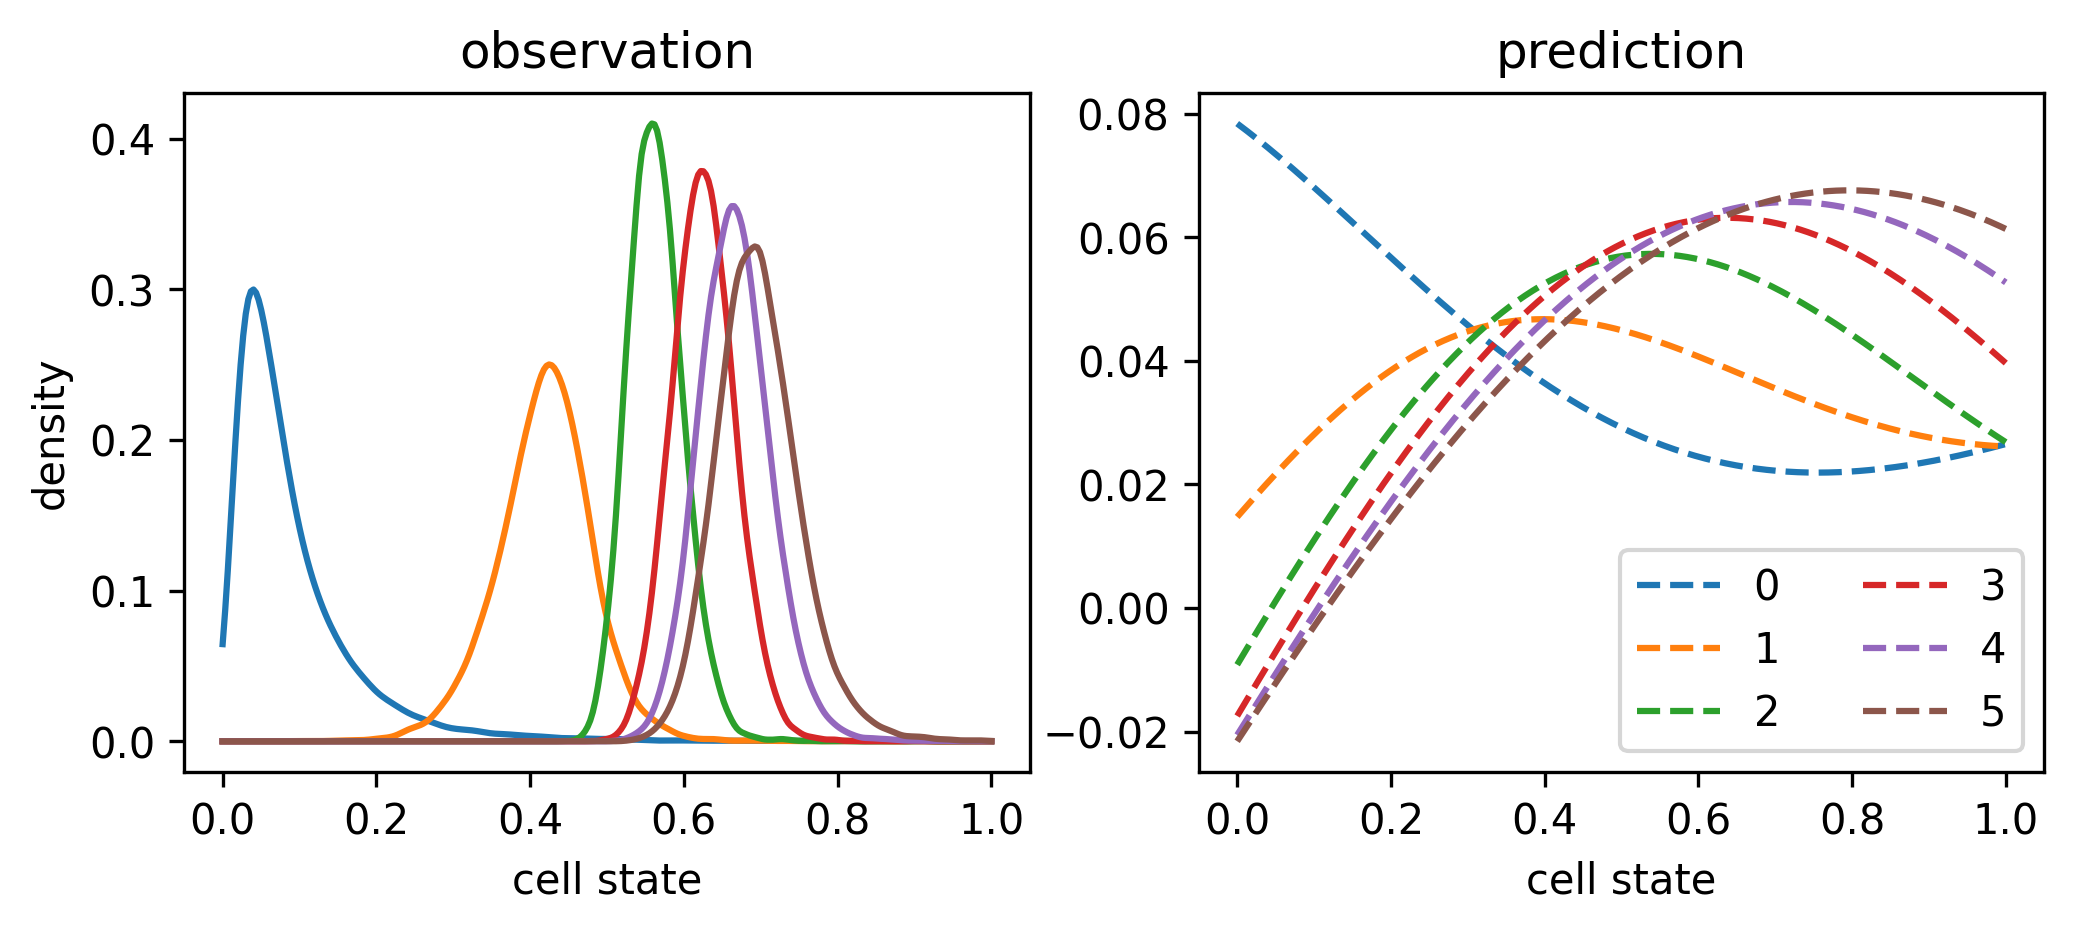

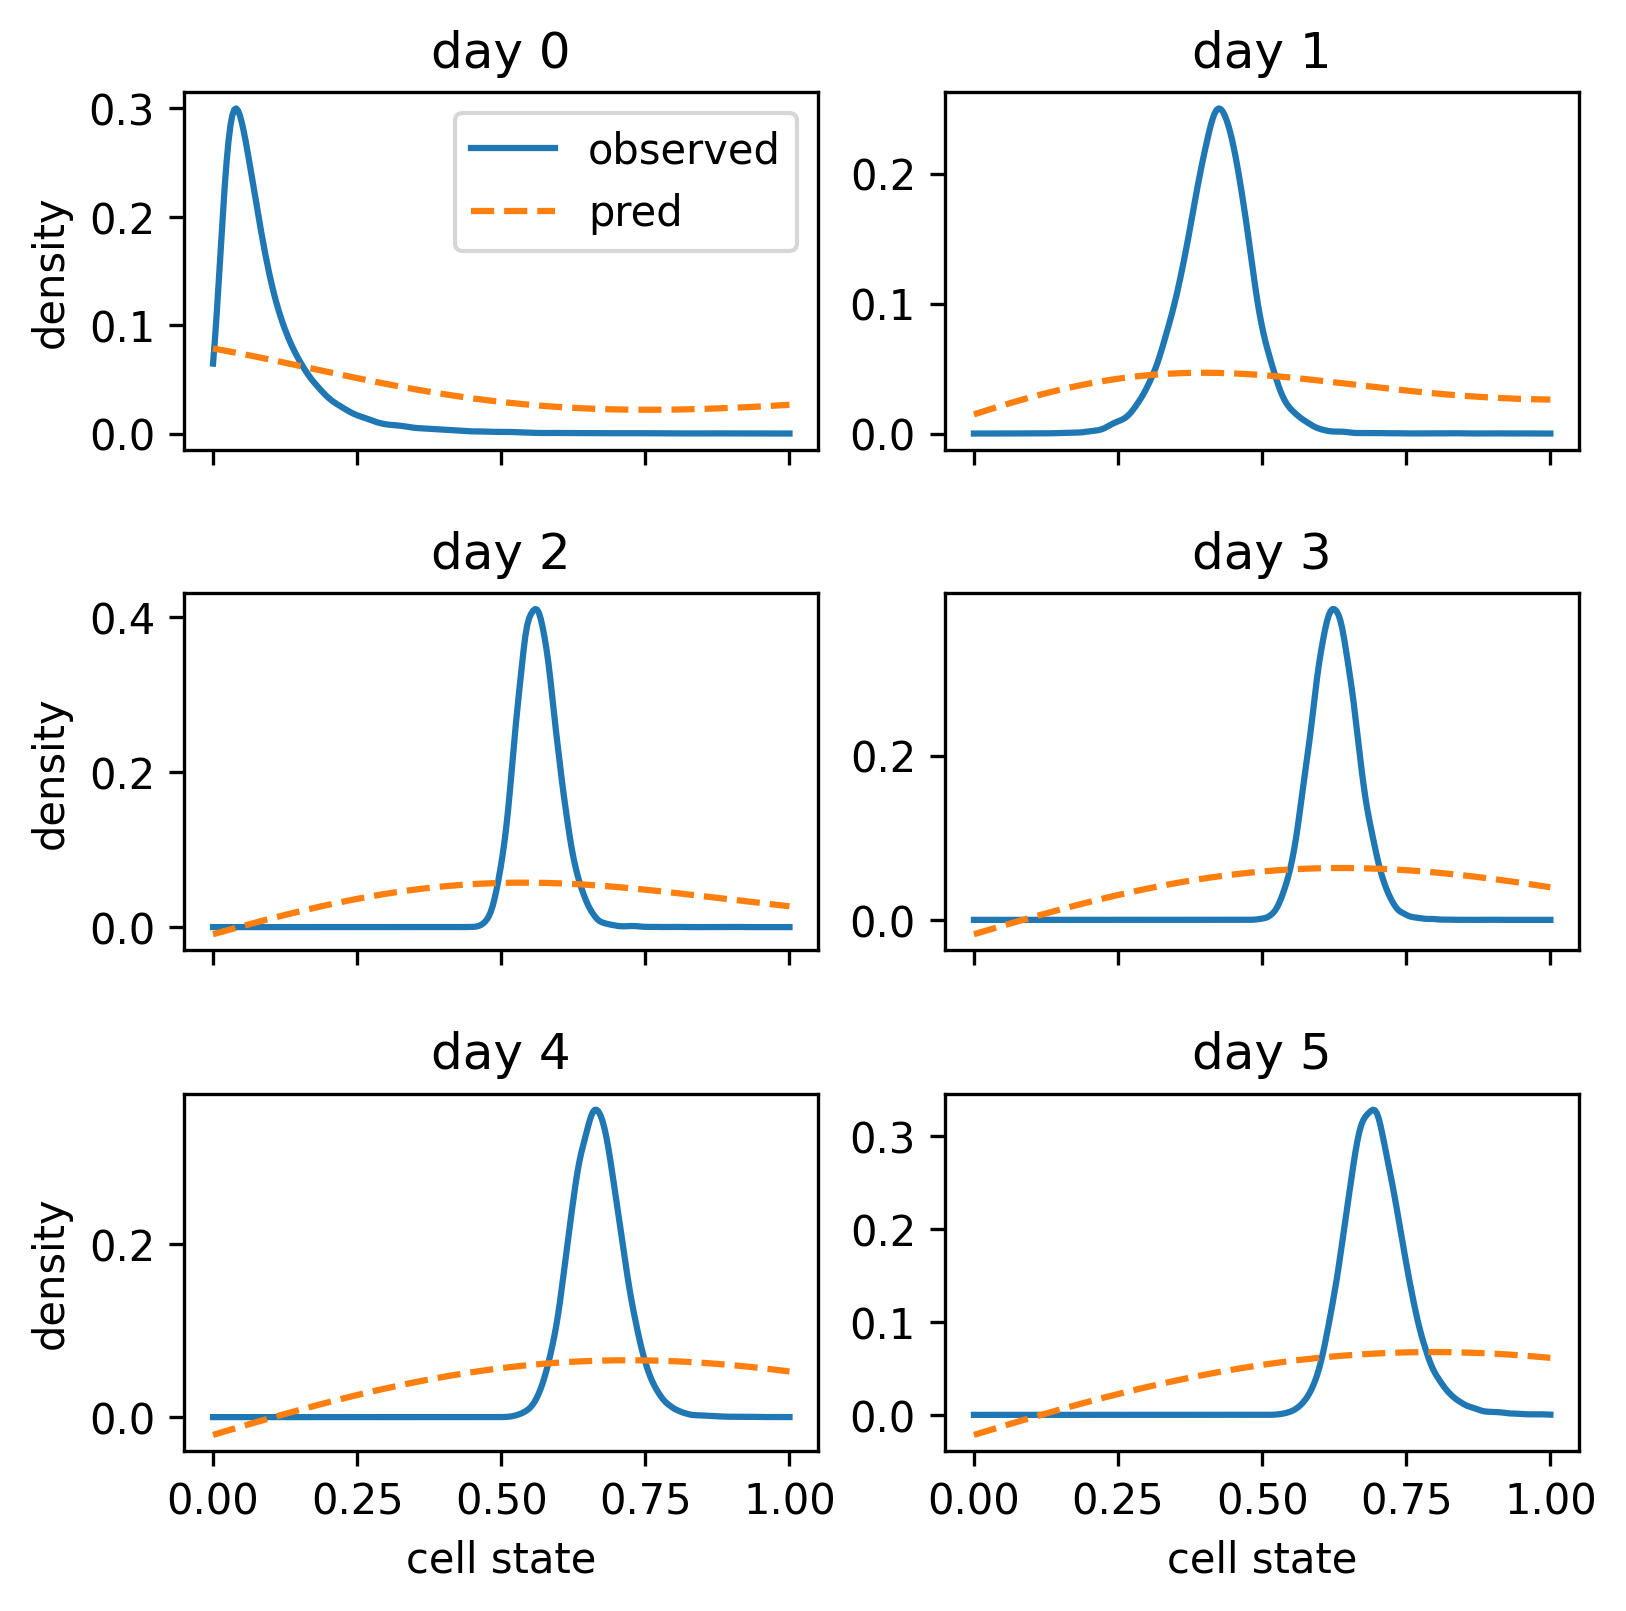

In [137]:
ckpt_path = "../logs/Cspline_PINN/lightning_logs/version_7/checkpoints/epoch=5-total_loss=16.55930901.ckpt"
kld_m = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

predict_and_vis(kld_m, data_batch, train_DS)

# adding KLD loss

In [110]:
import pl

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


[8.905369  7.096349  7.3121705 7.8231654 7.964172  8.005749 ]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


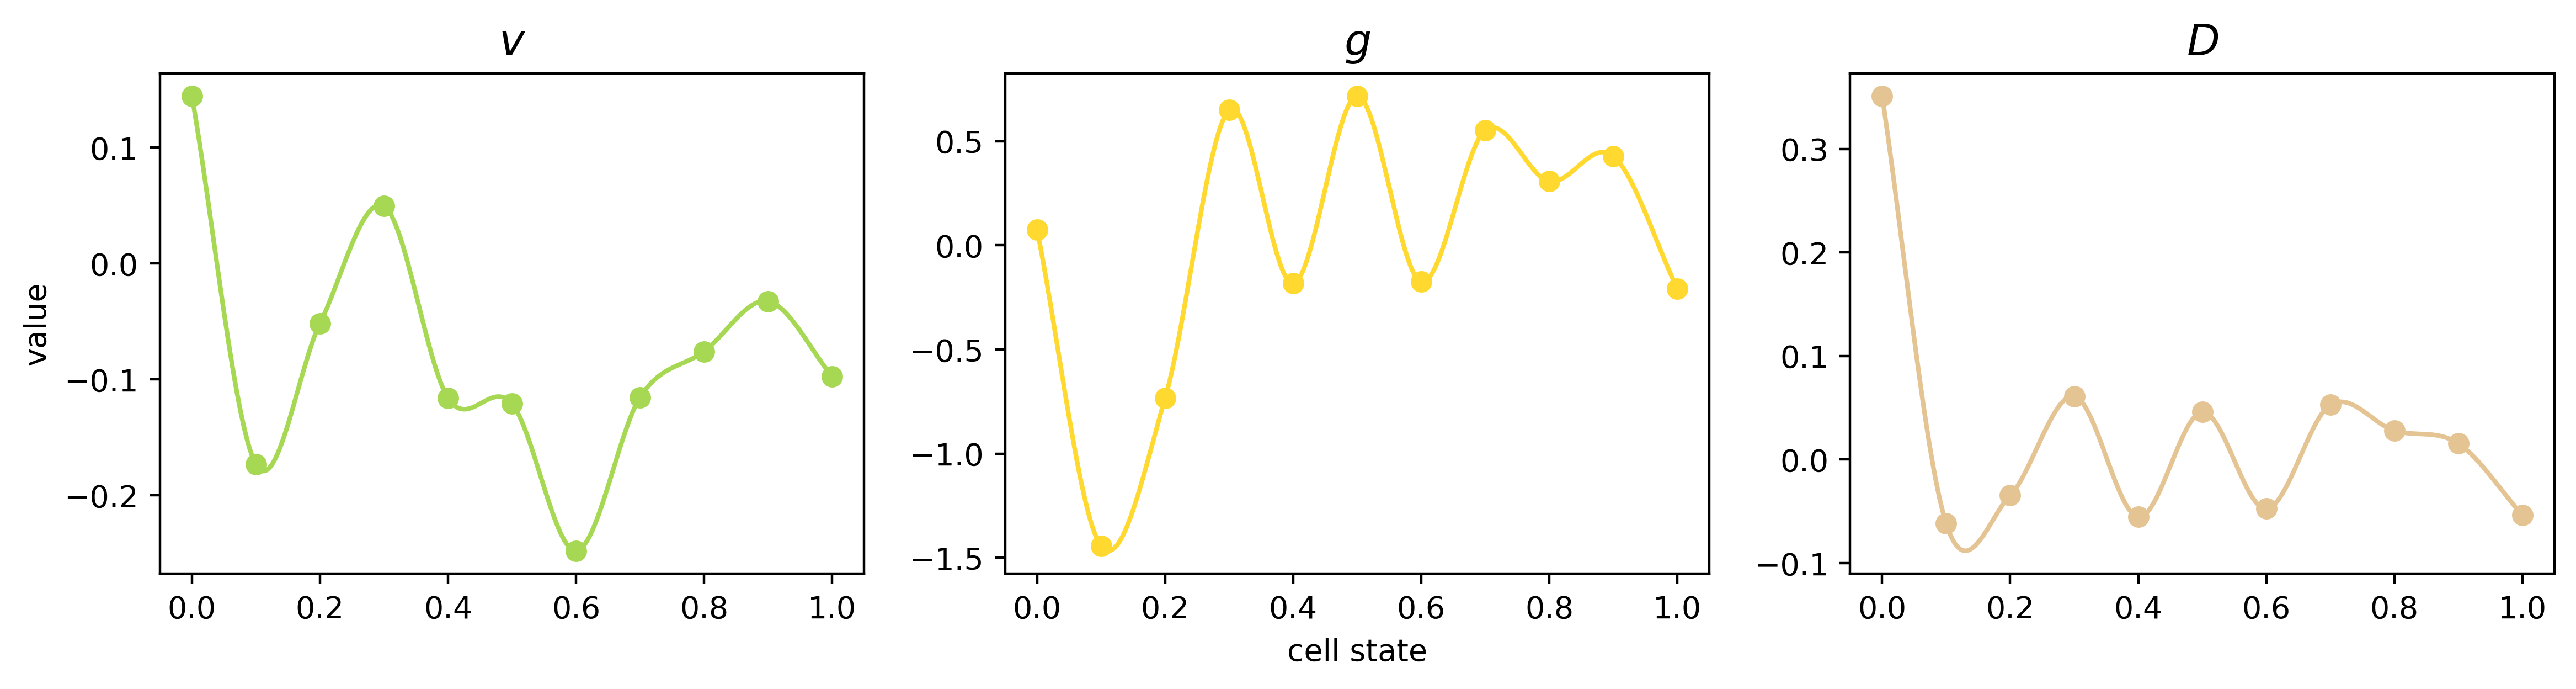

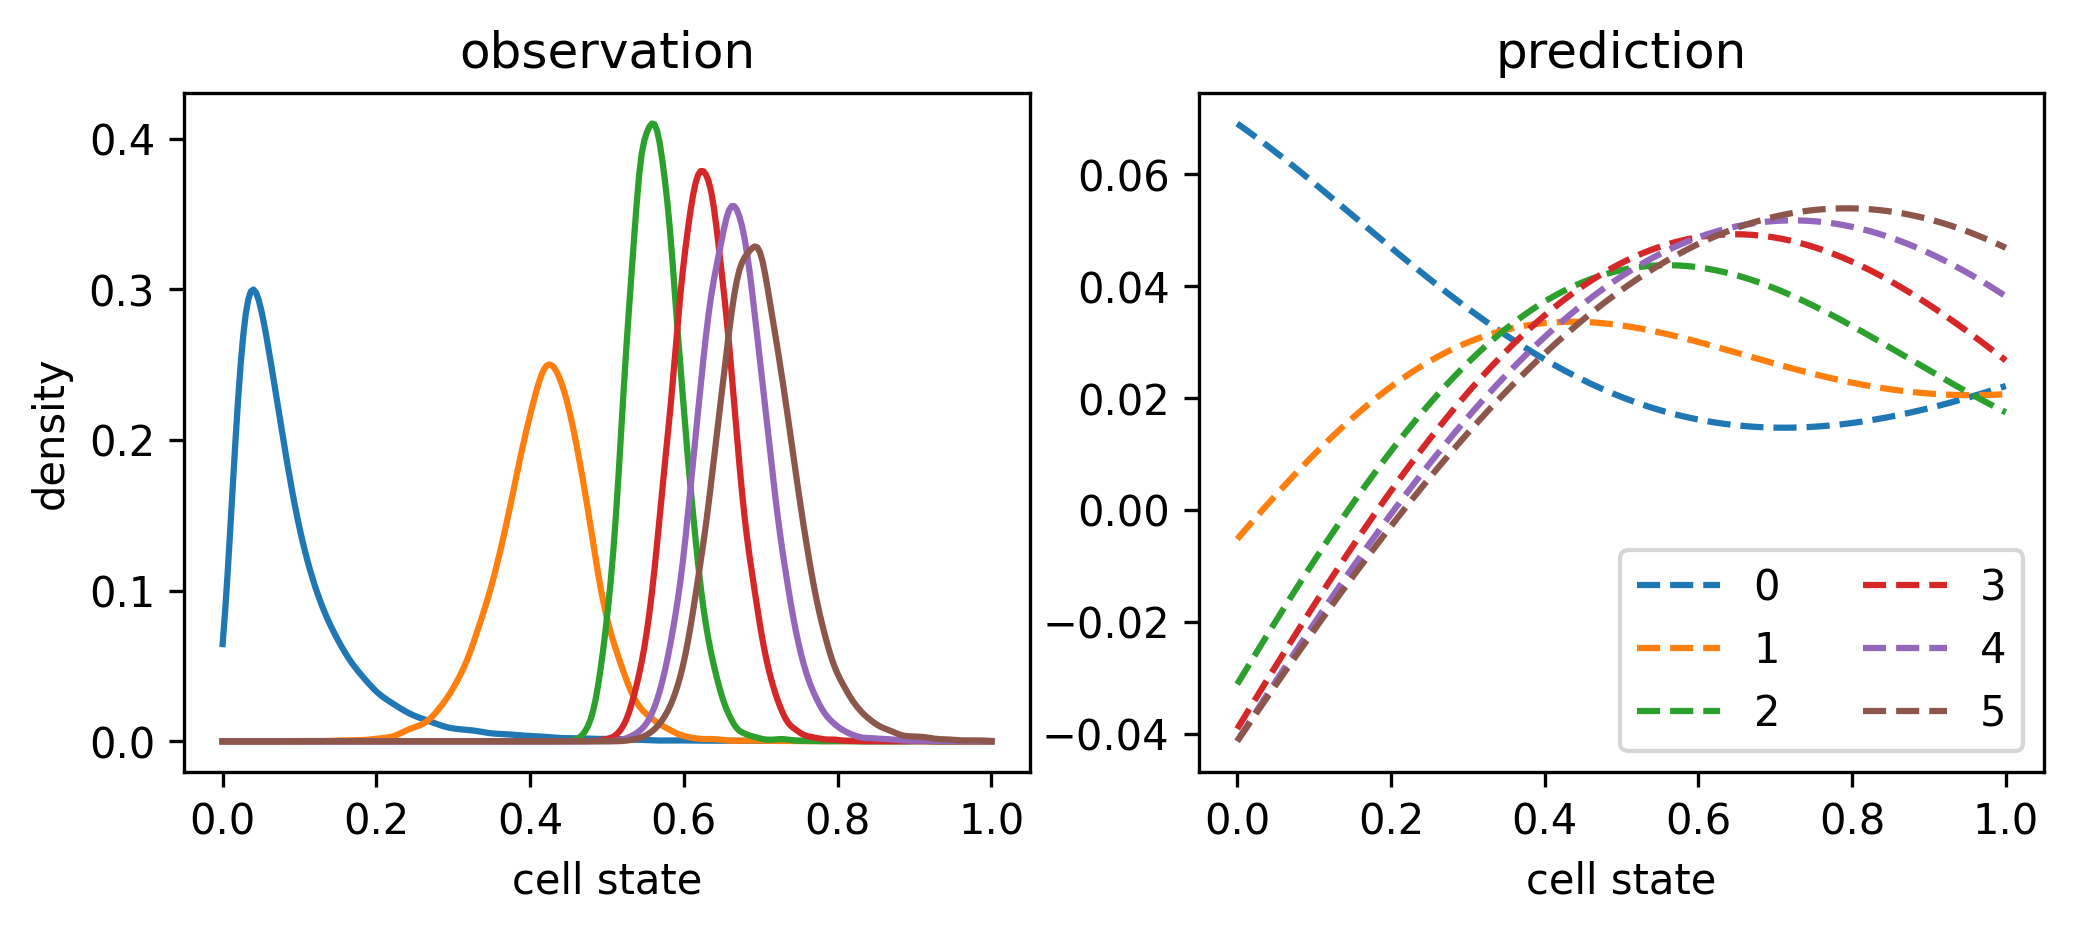

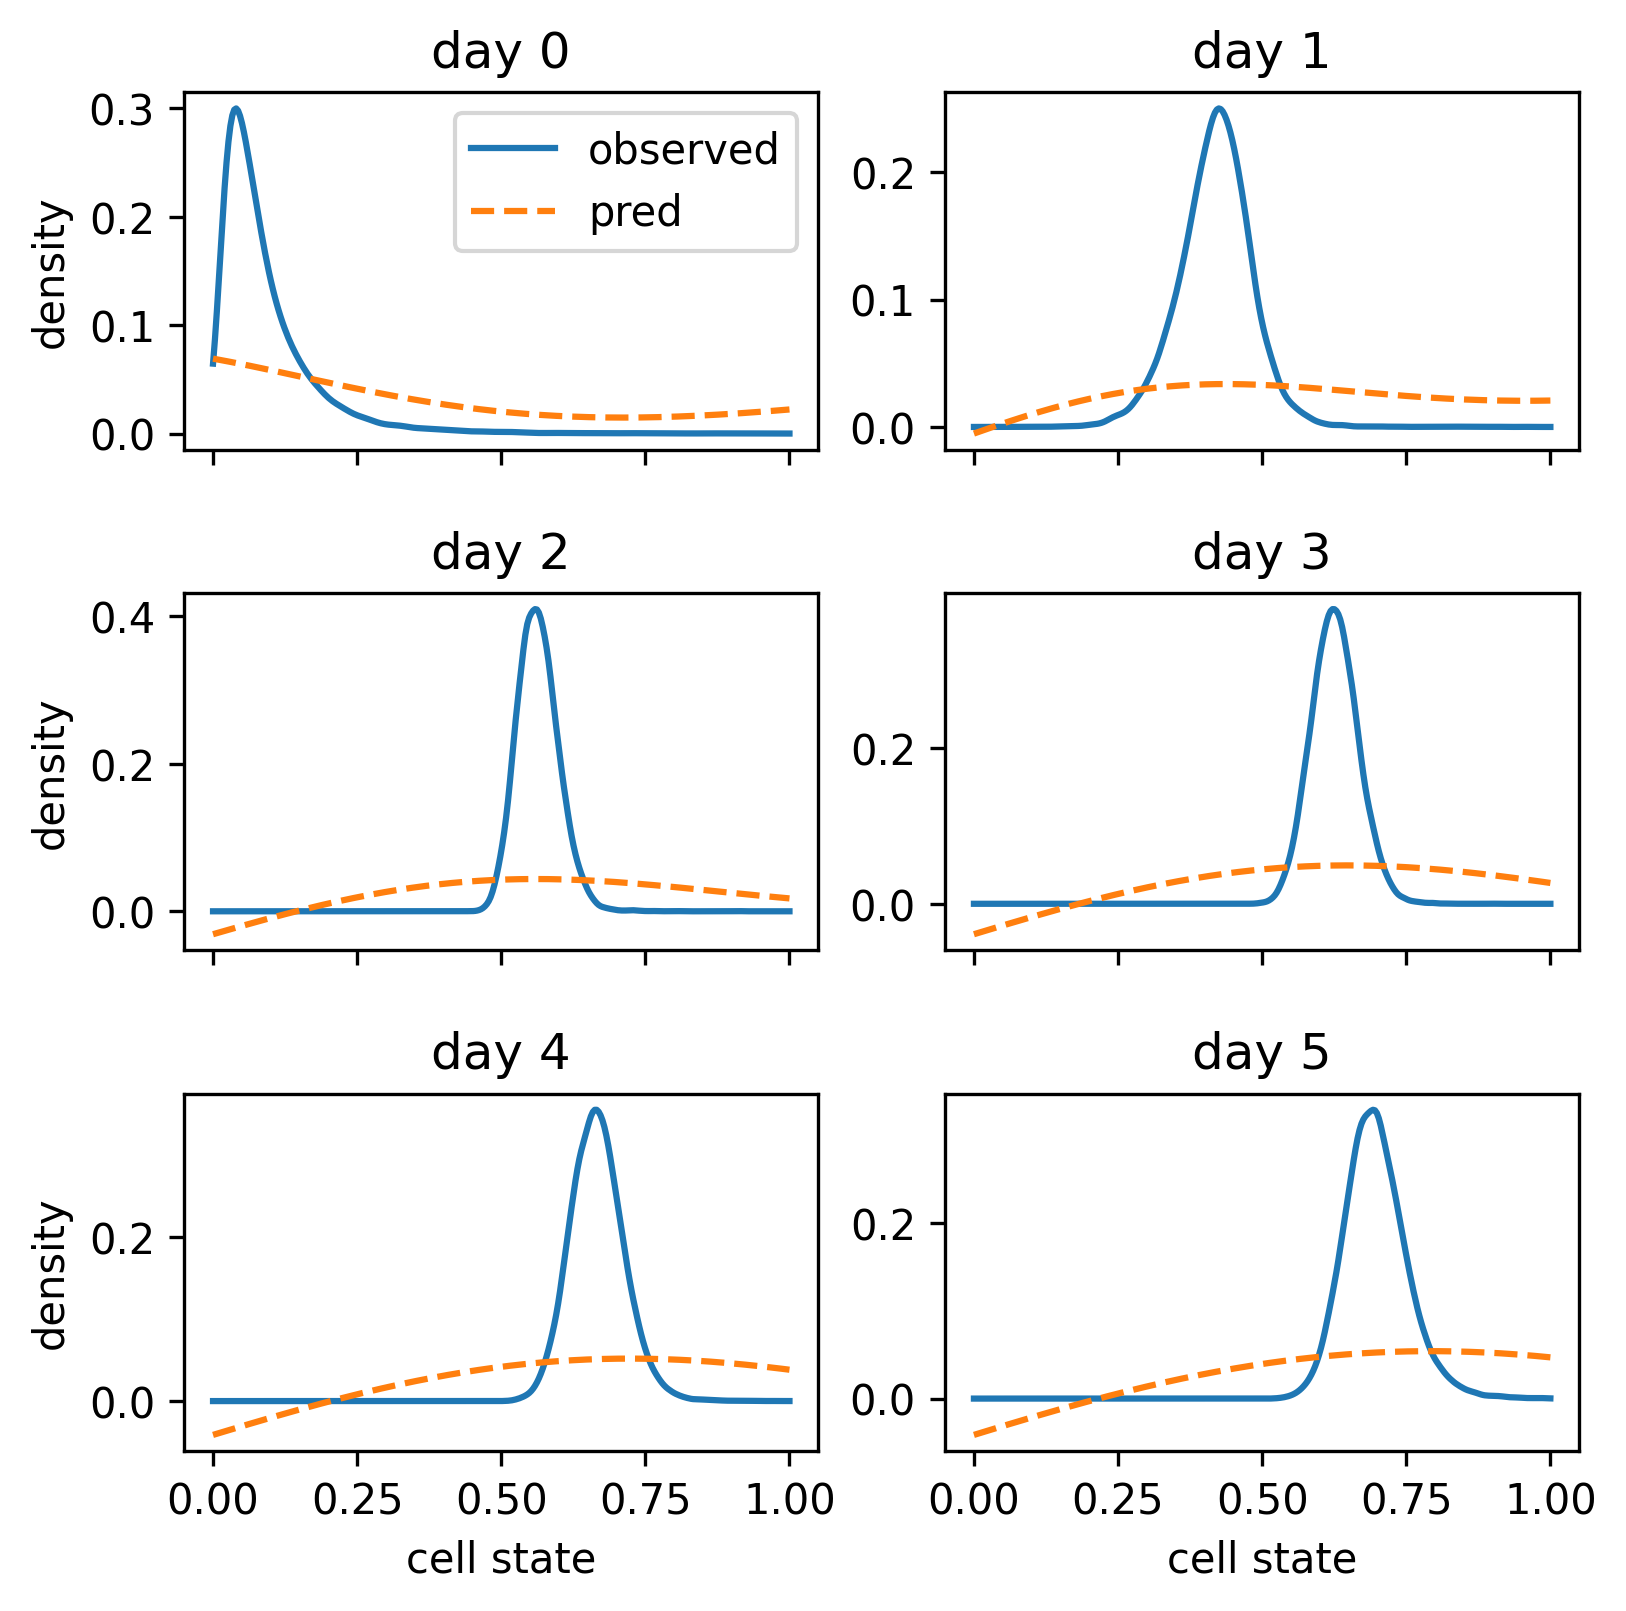

In [135]:
ckpt_path = "../logs/Cspline_PINN/lightning_logs/version_8/checkpoints/epoch=2-total_loss=19.90981674.ckpt"
kld_m = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

predict_and_vis(kld_m, data_batch, train_DS)

# KLD from scratch

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


[10.558567   7.089071   7.1224804  8.004602   7.931767   7.0609565]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


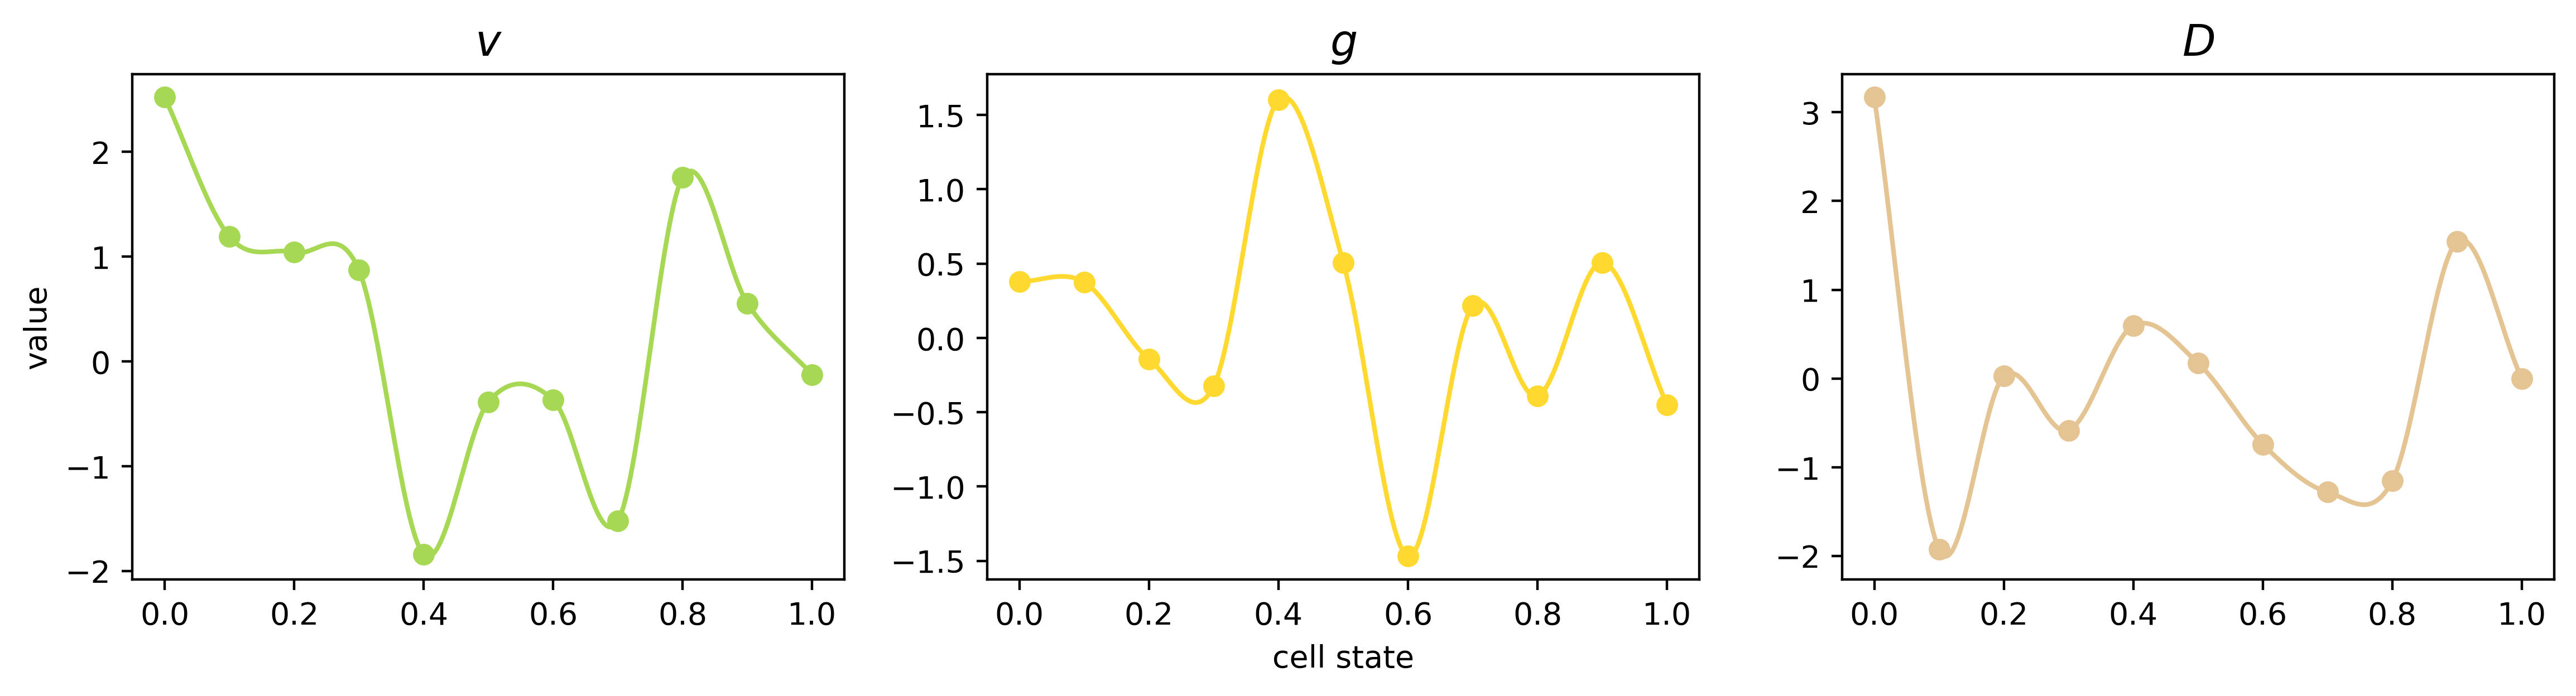

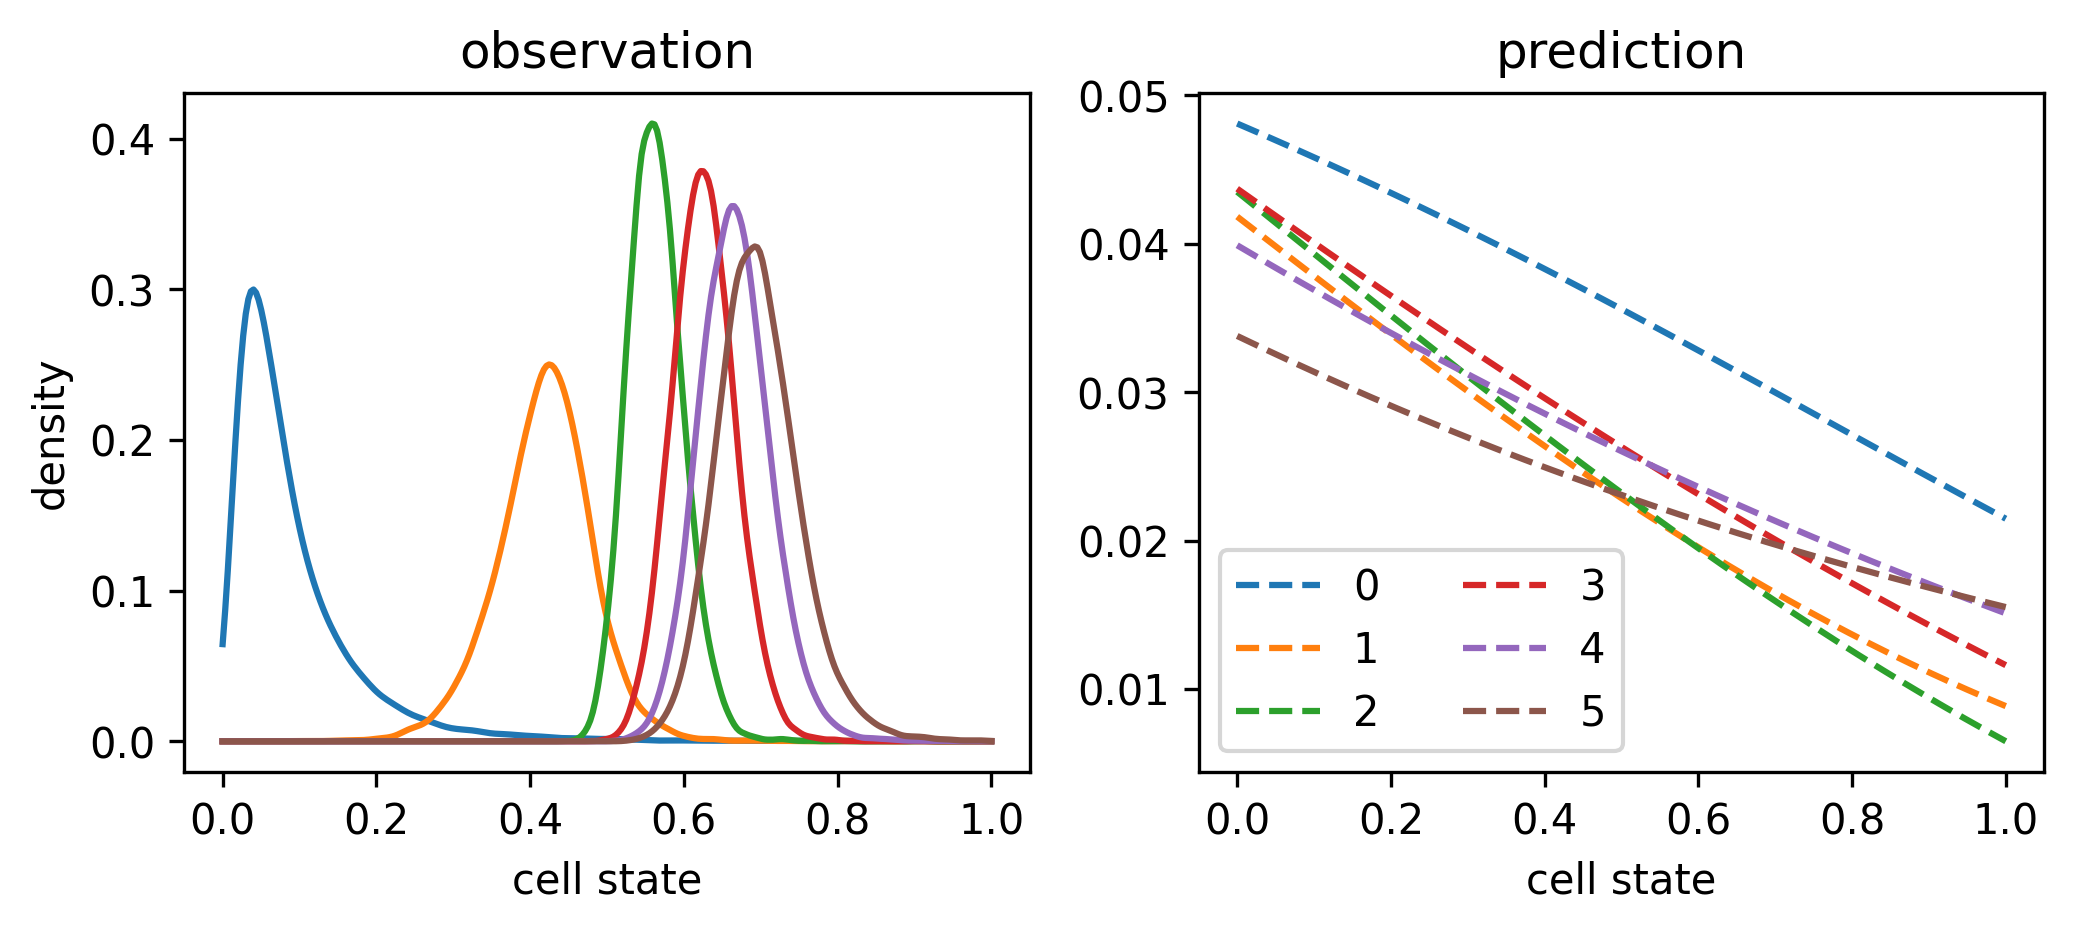

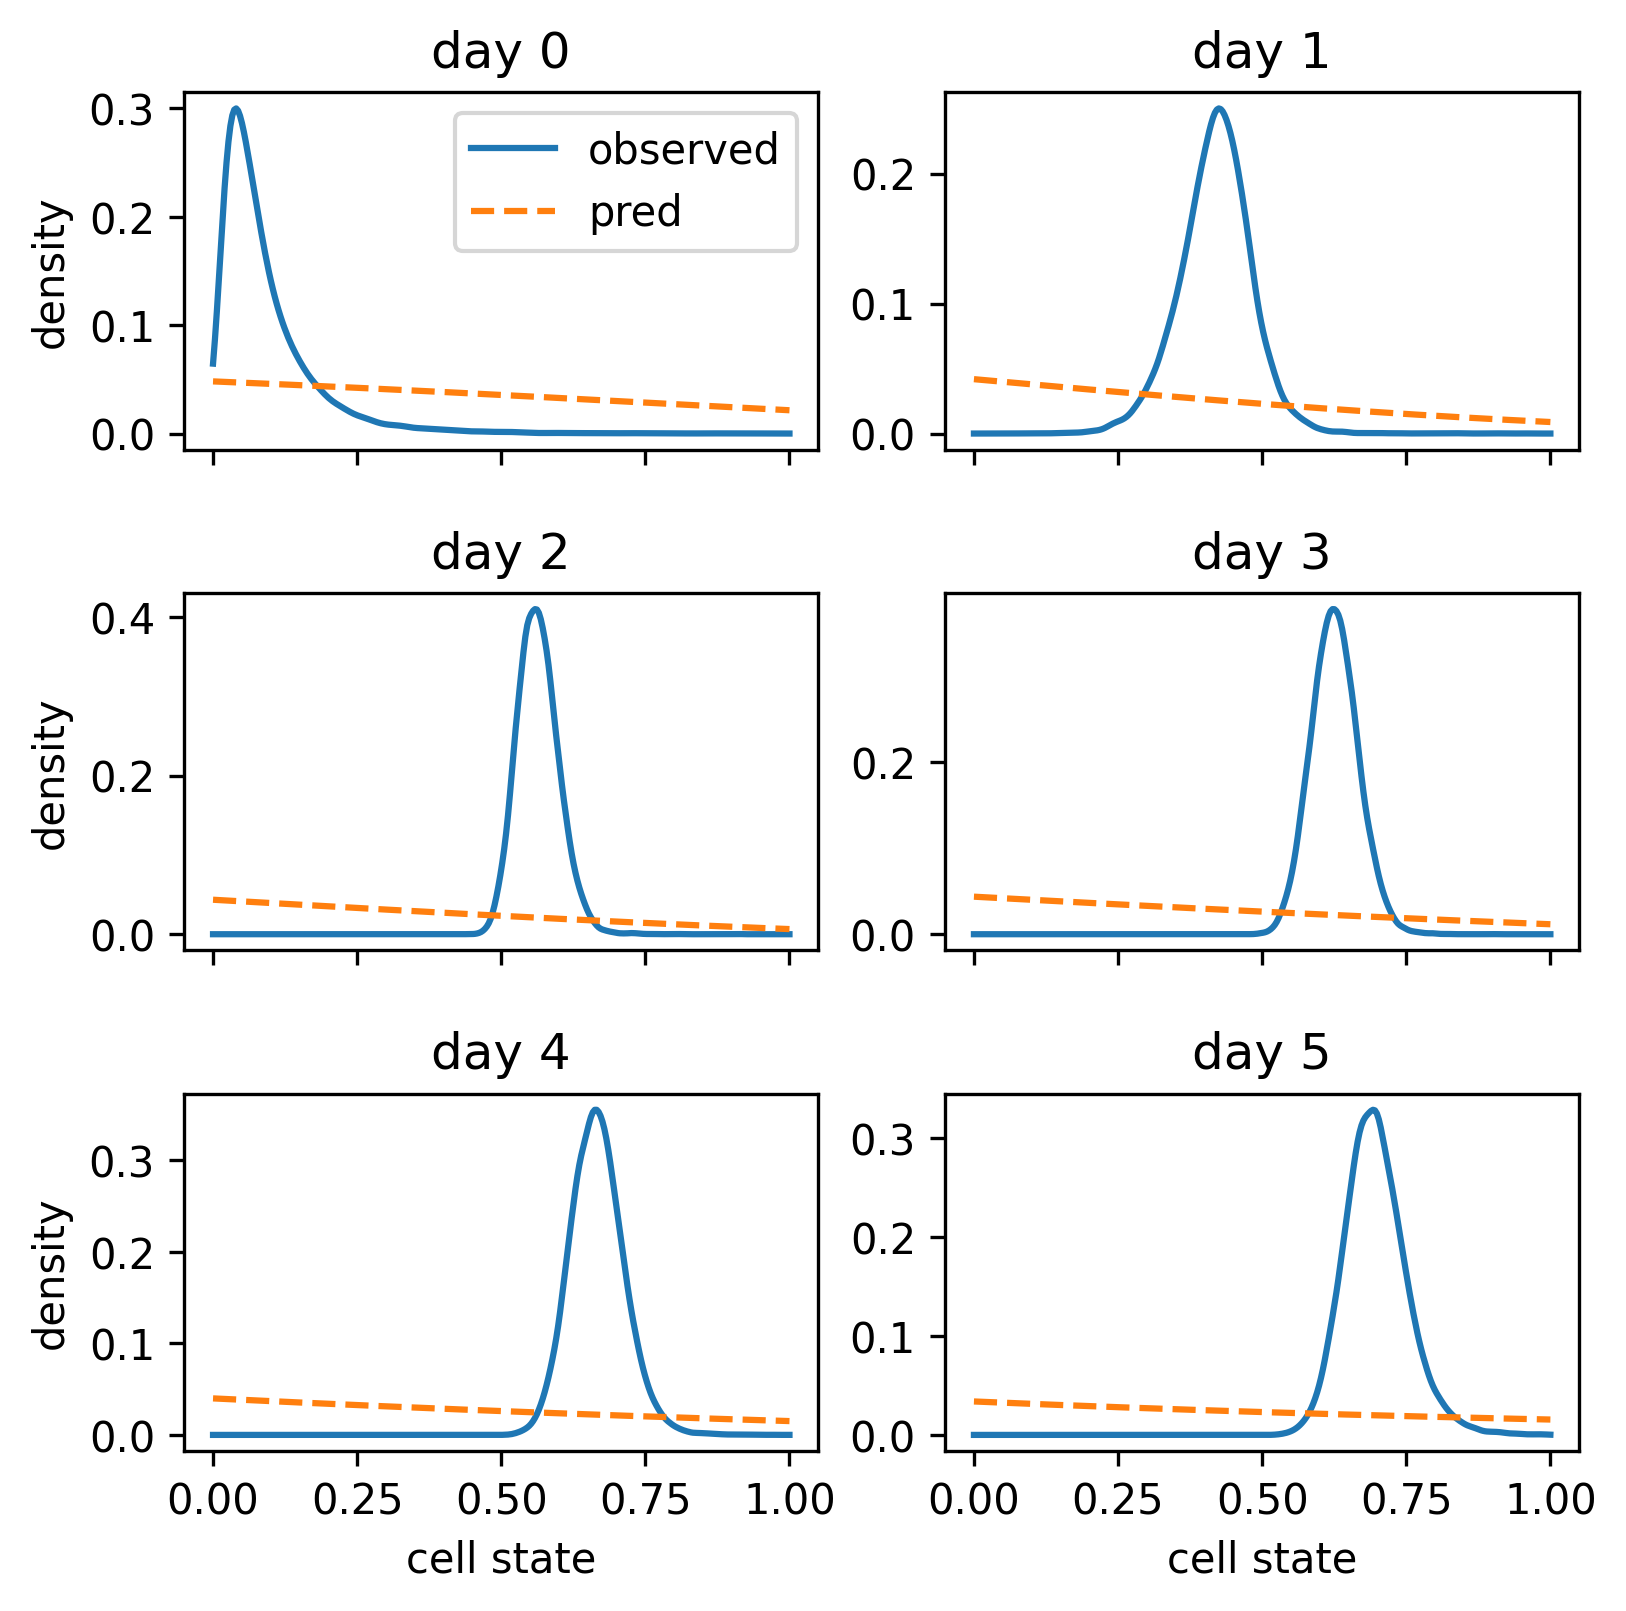

In [136]:
ckpt_path = "../logs/Cspline_PINN/lightning_logs/version_9/checkpoints/epoch=1-total_loss=75.29361725.ckpt"
kld_m2 = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

predict_and_vis(kld_m2, data_batch, train_DS)

# KLD from later

In [138]:
ckpt_path3 = "../logs/Cspline_PINN/lightning_logs/version_9/checkpoints/epoch=5-total_loss=208.62158203.ckpt"
kld_m3 = models.Cspline_PINN.load_from_checkpoint(ckpt_path3)

[69.14229   52.31921   24.573383   5.3425674 -3.6664019 -7.329452 ]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


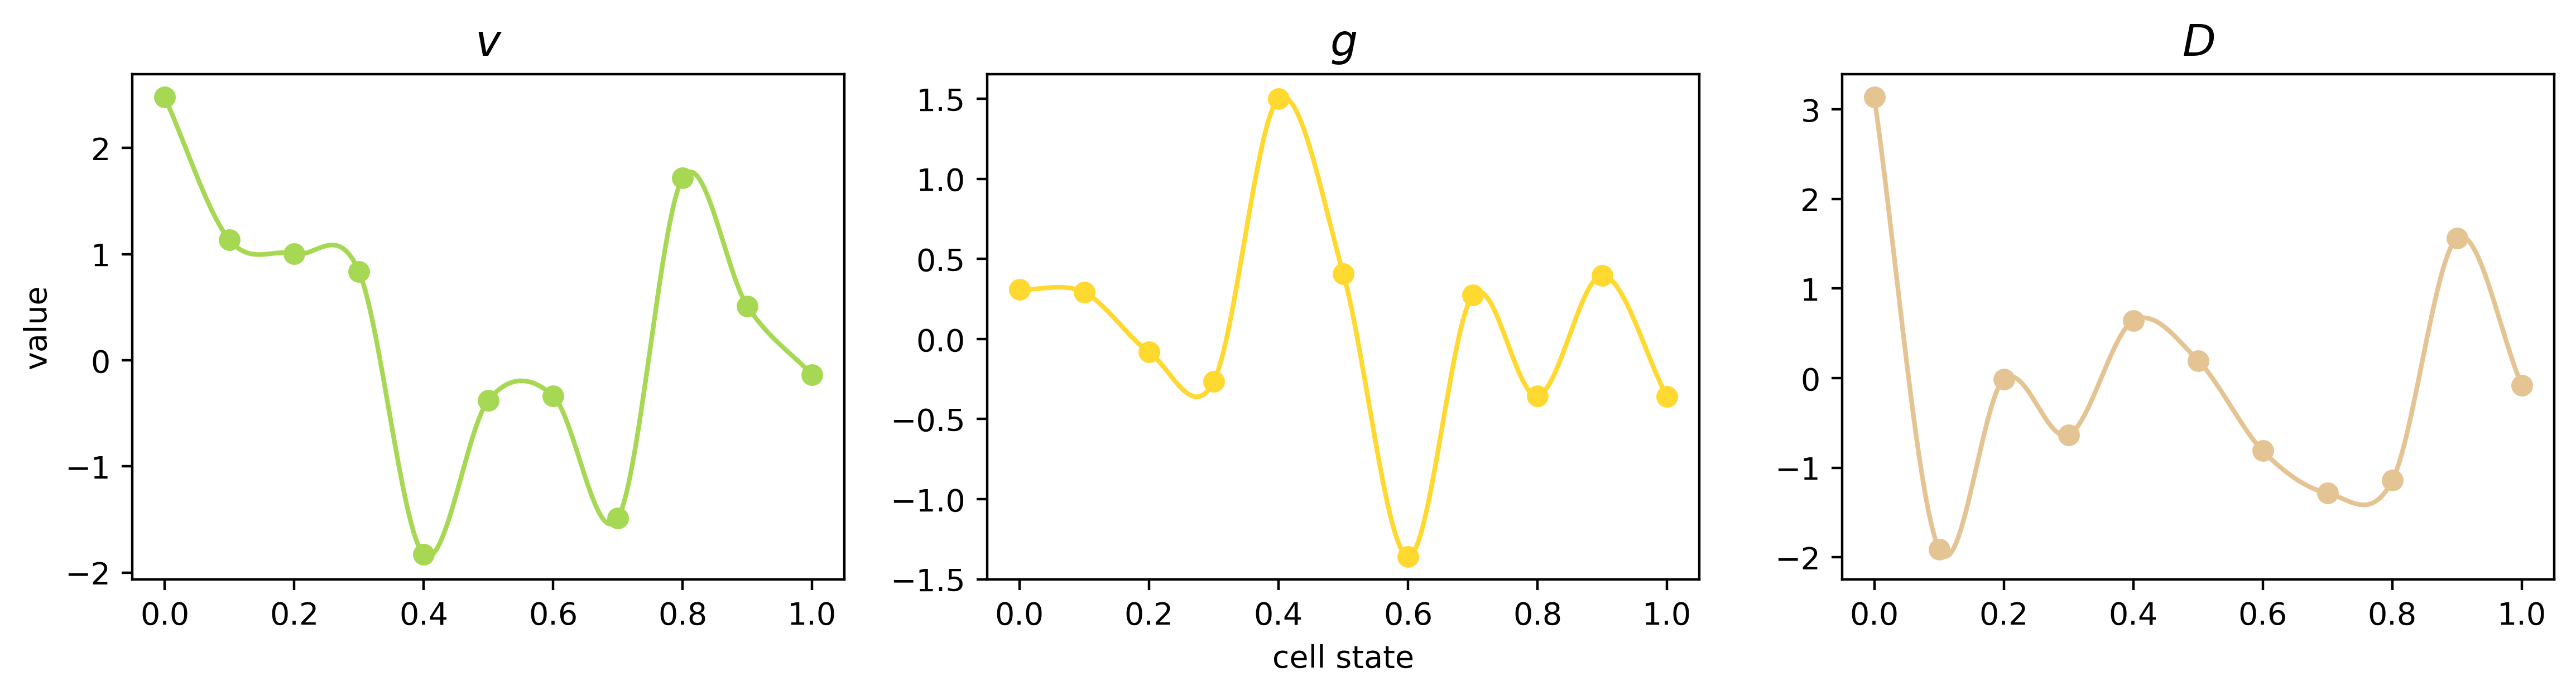

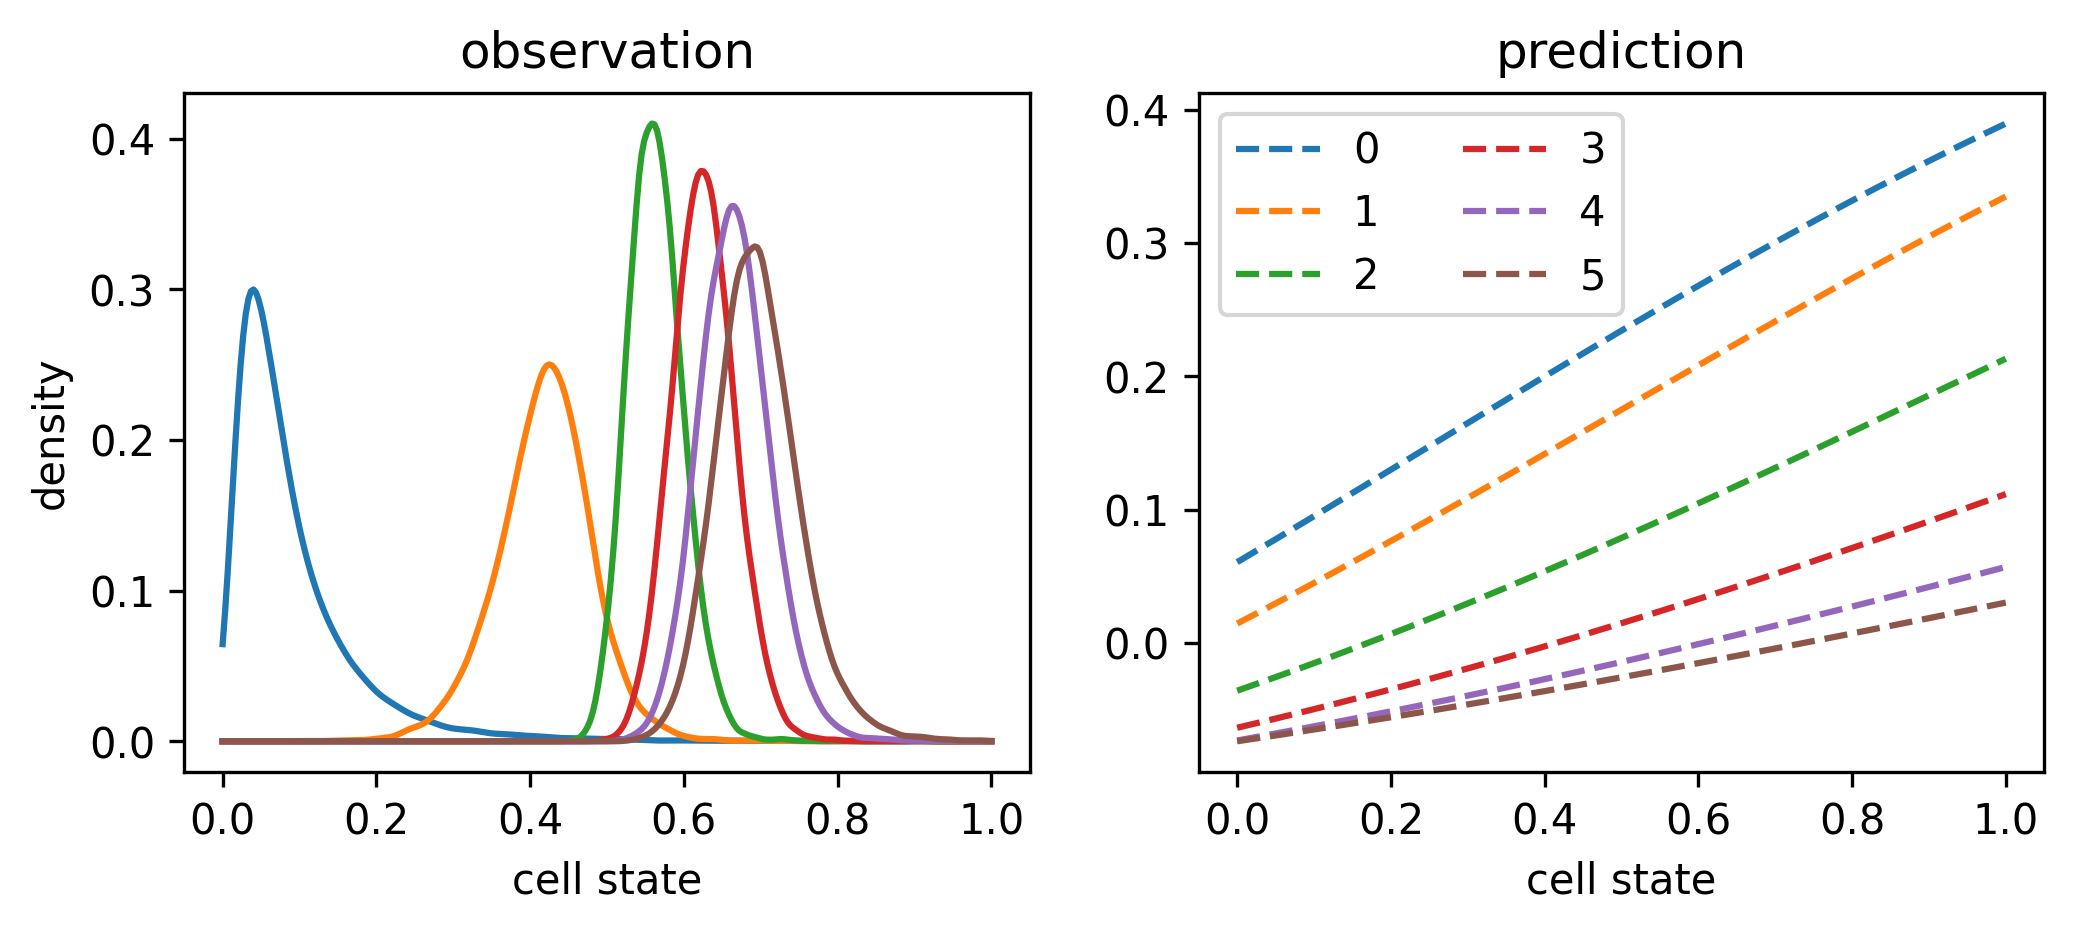

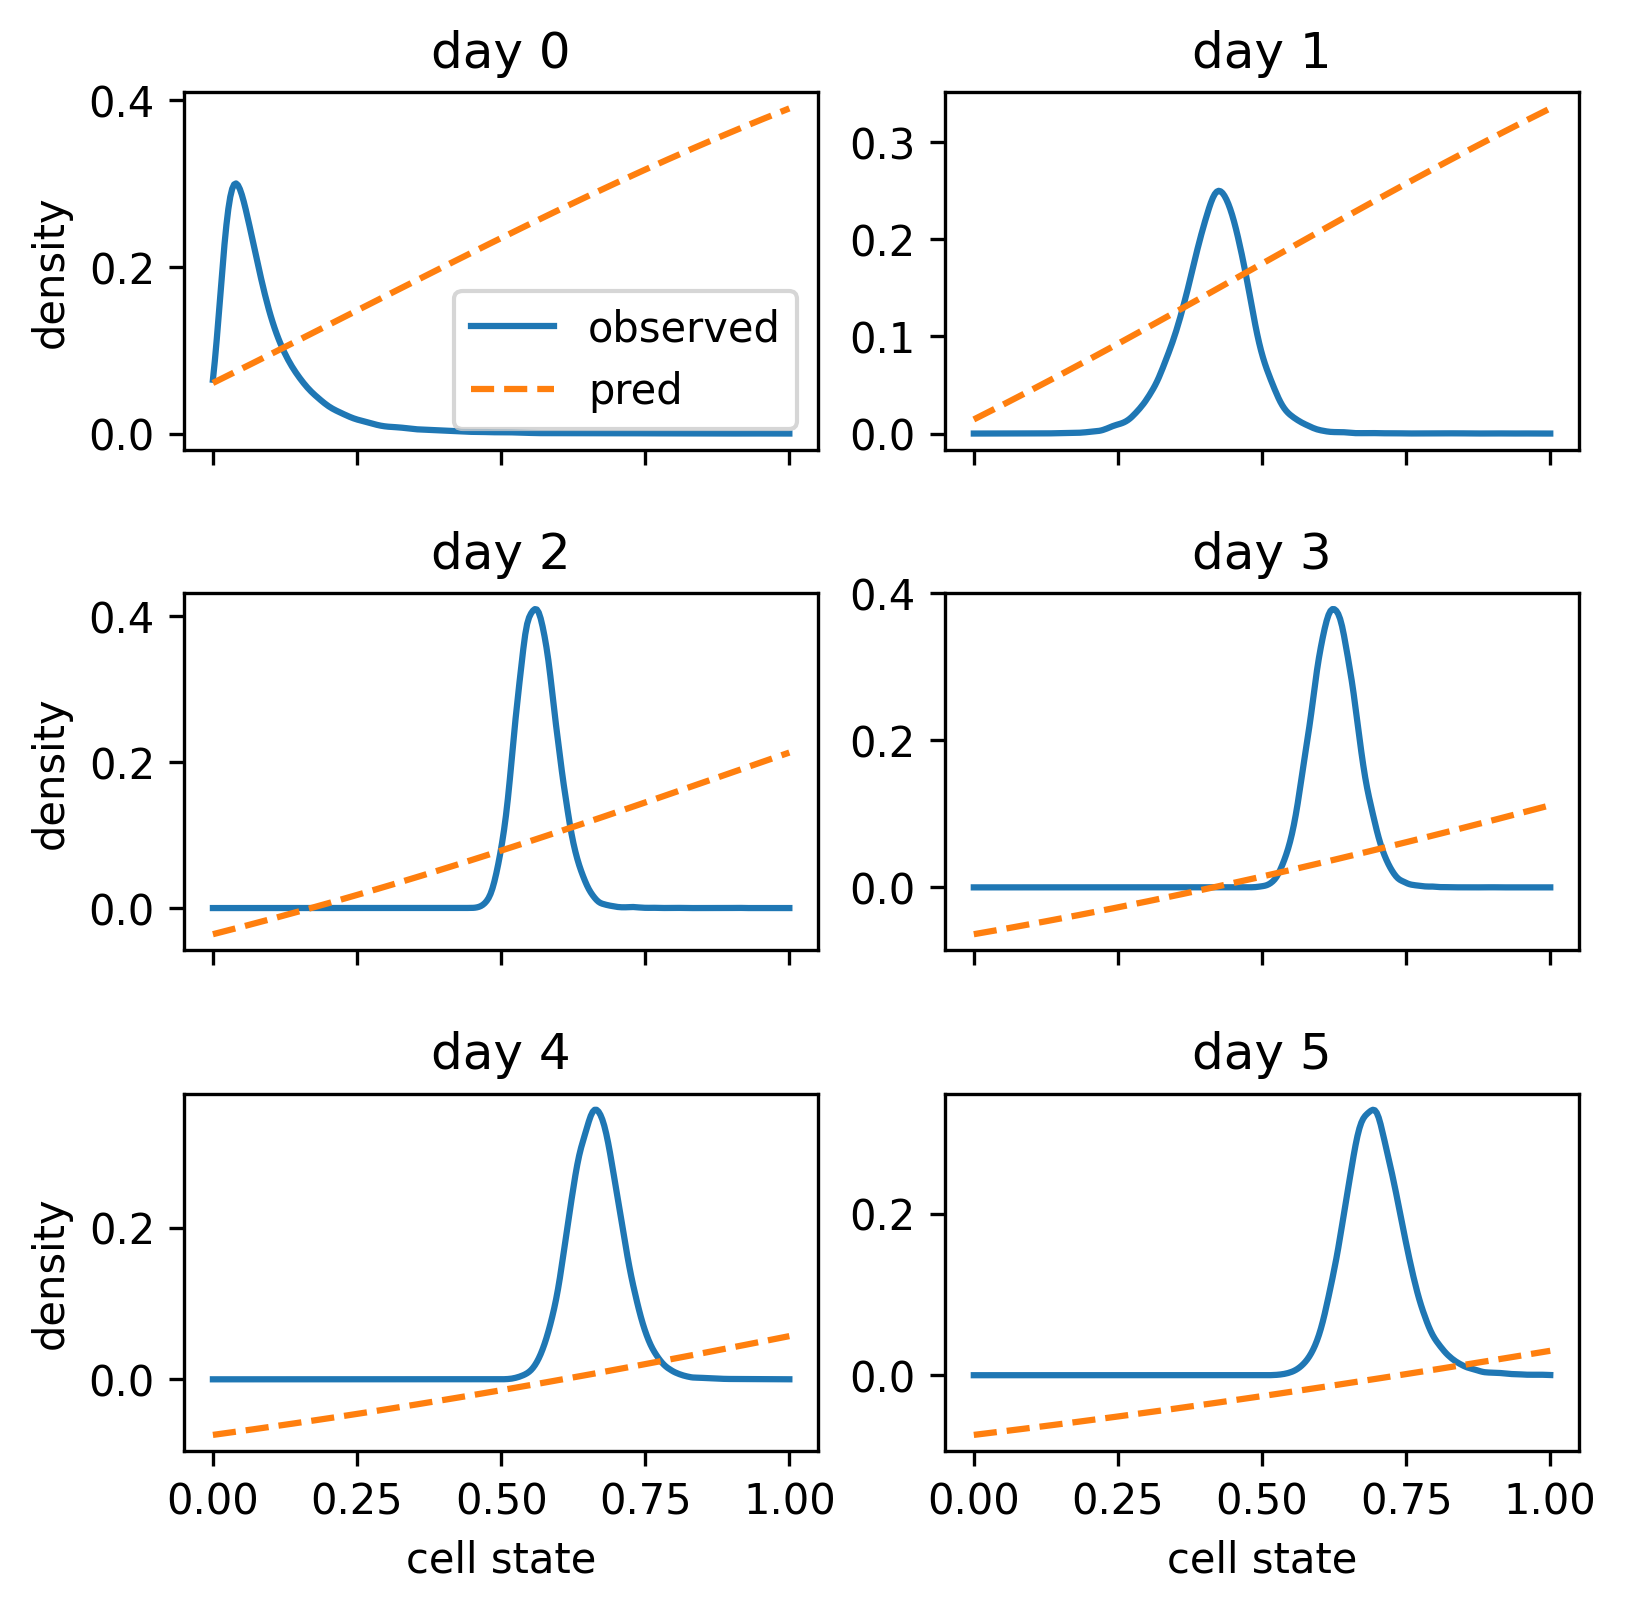

In [139]:
predict_and_vis(kld_m3, data_batch, train_DS)

# only KLD

In [140]:
ckpt_path = "../logs/Cspline_PINN/lightning_logs/version_10/checkpoints/epoch=16-total_loss=6.81155491.ckpt"
kld_m2 = models.Cspline_PINN.load_from_checkpoint(ckpt_path)

[12.756876 11.352649 10.070501 10.278593 11.272467 12.508734]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


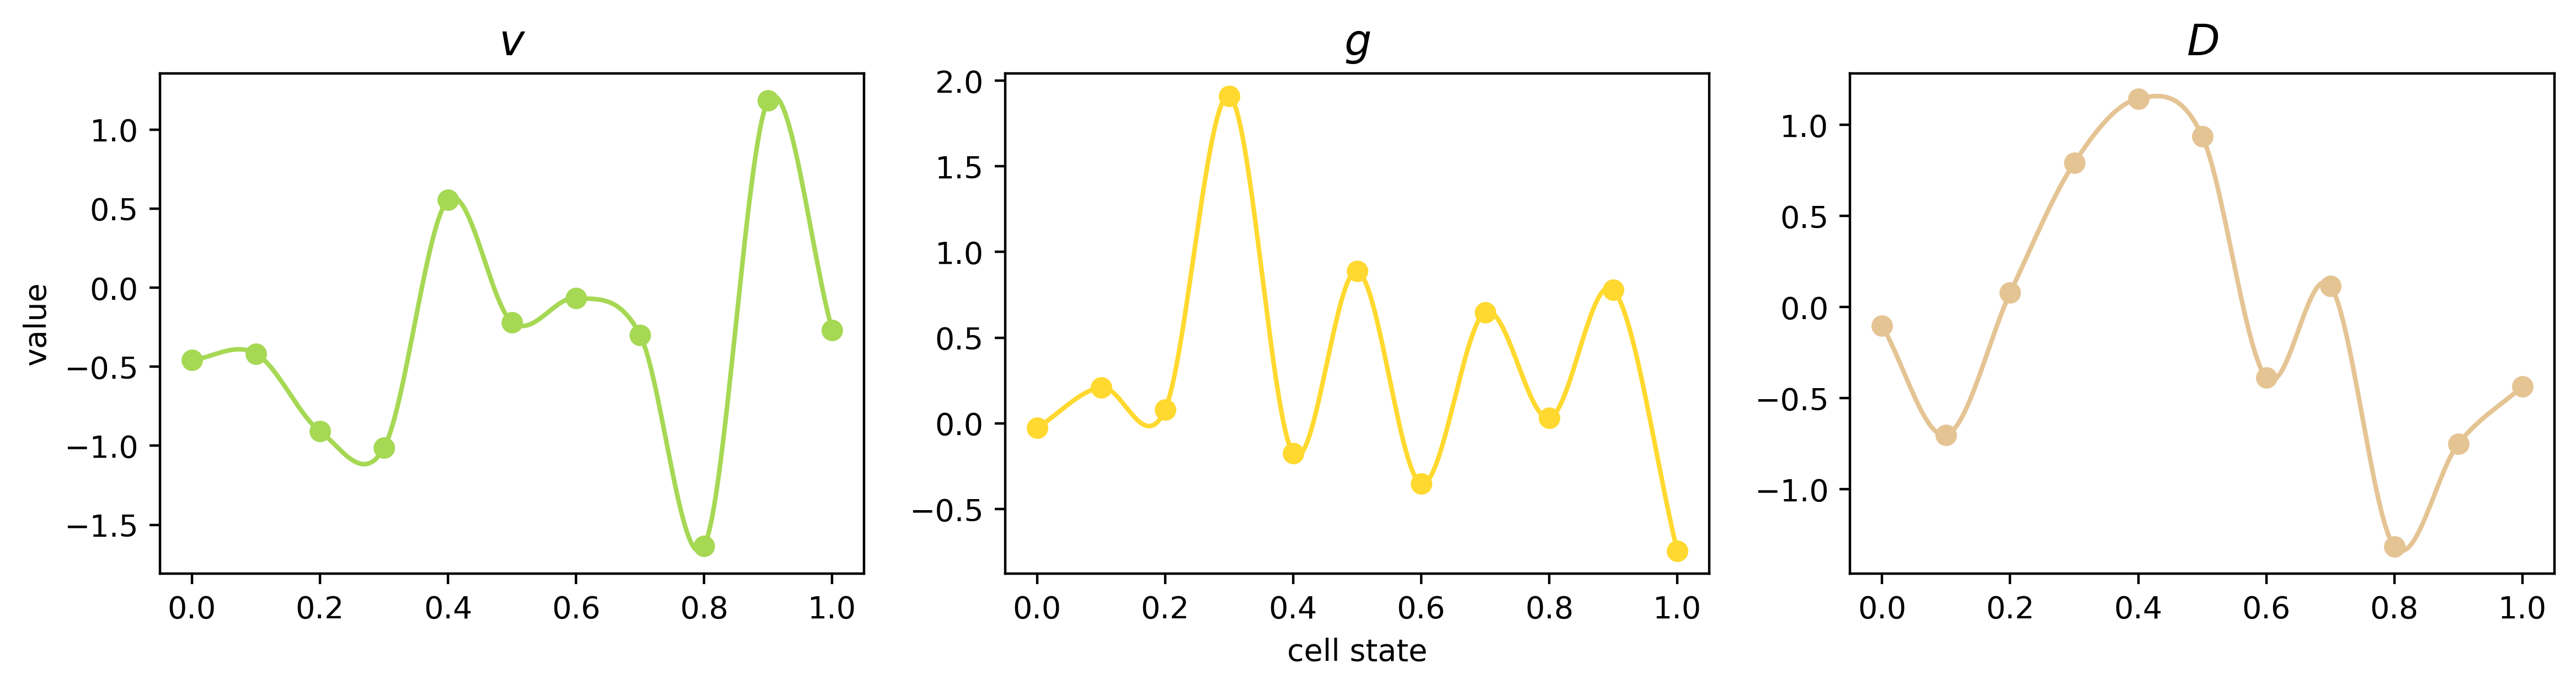

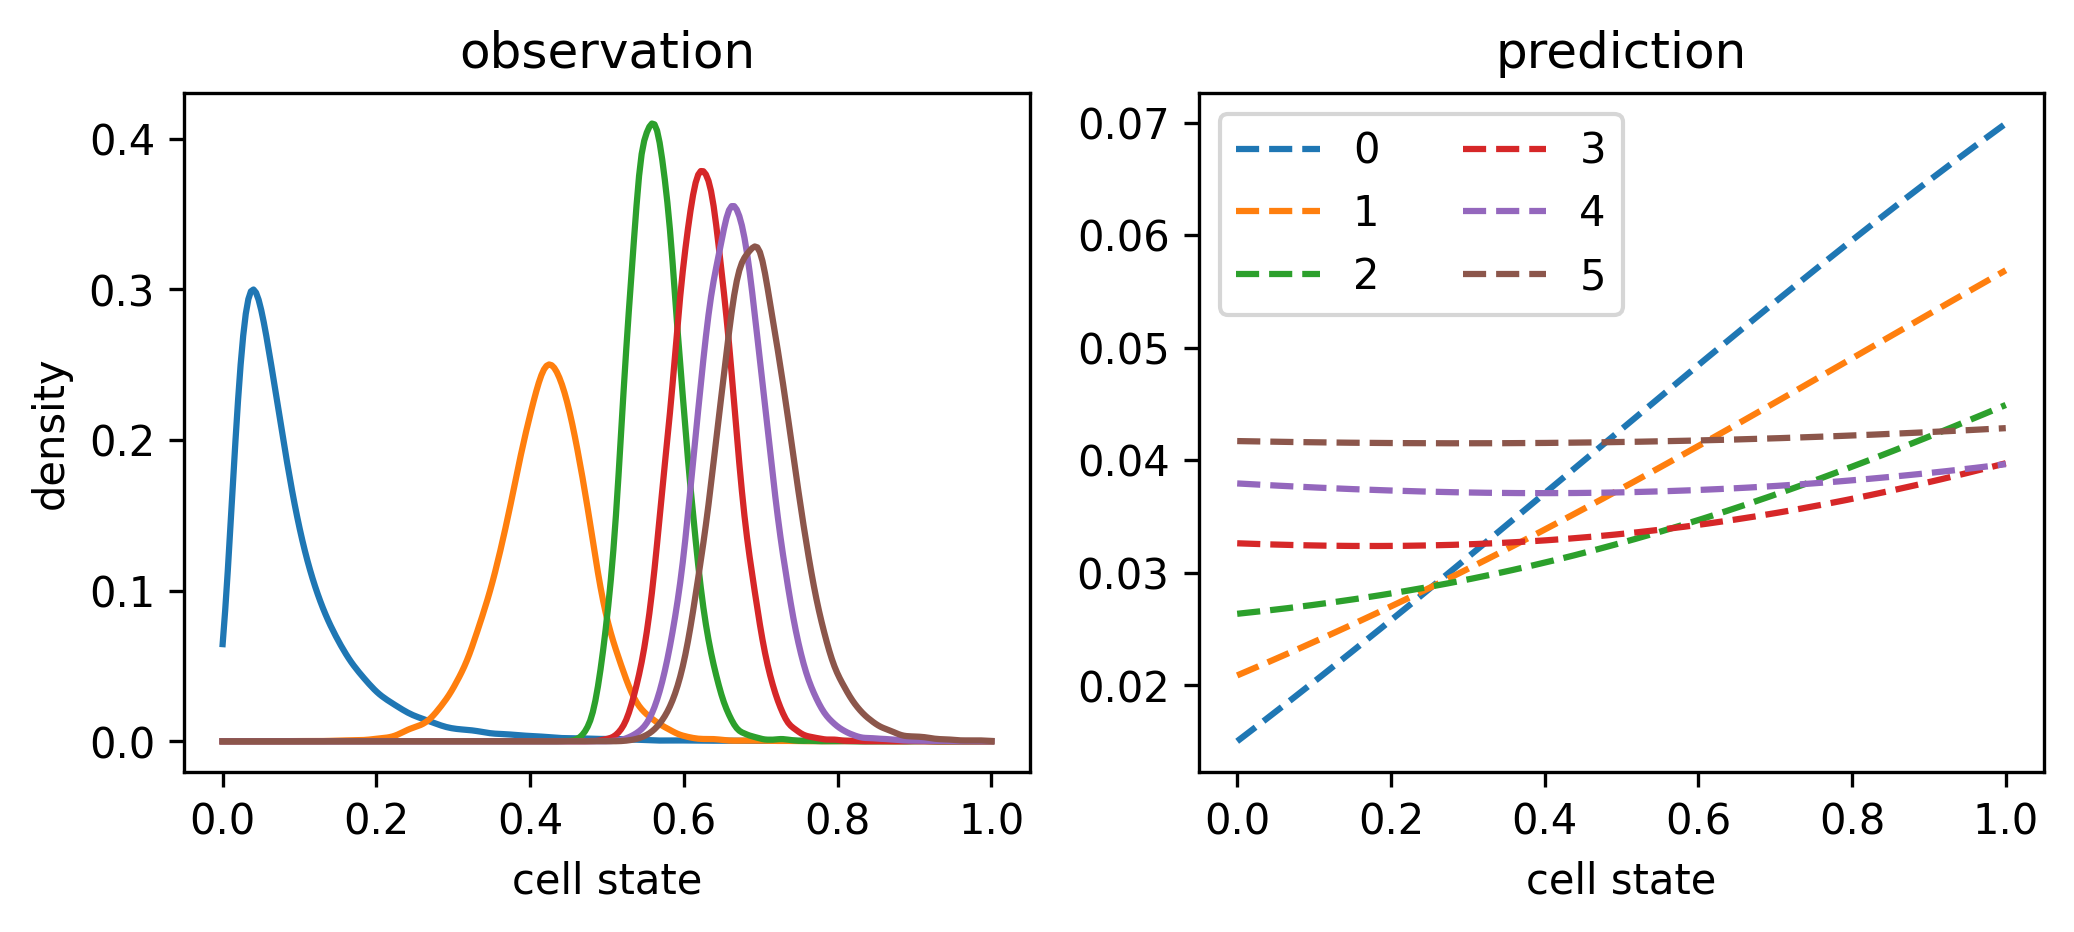

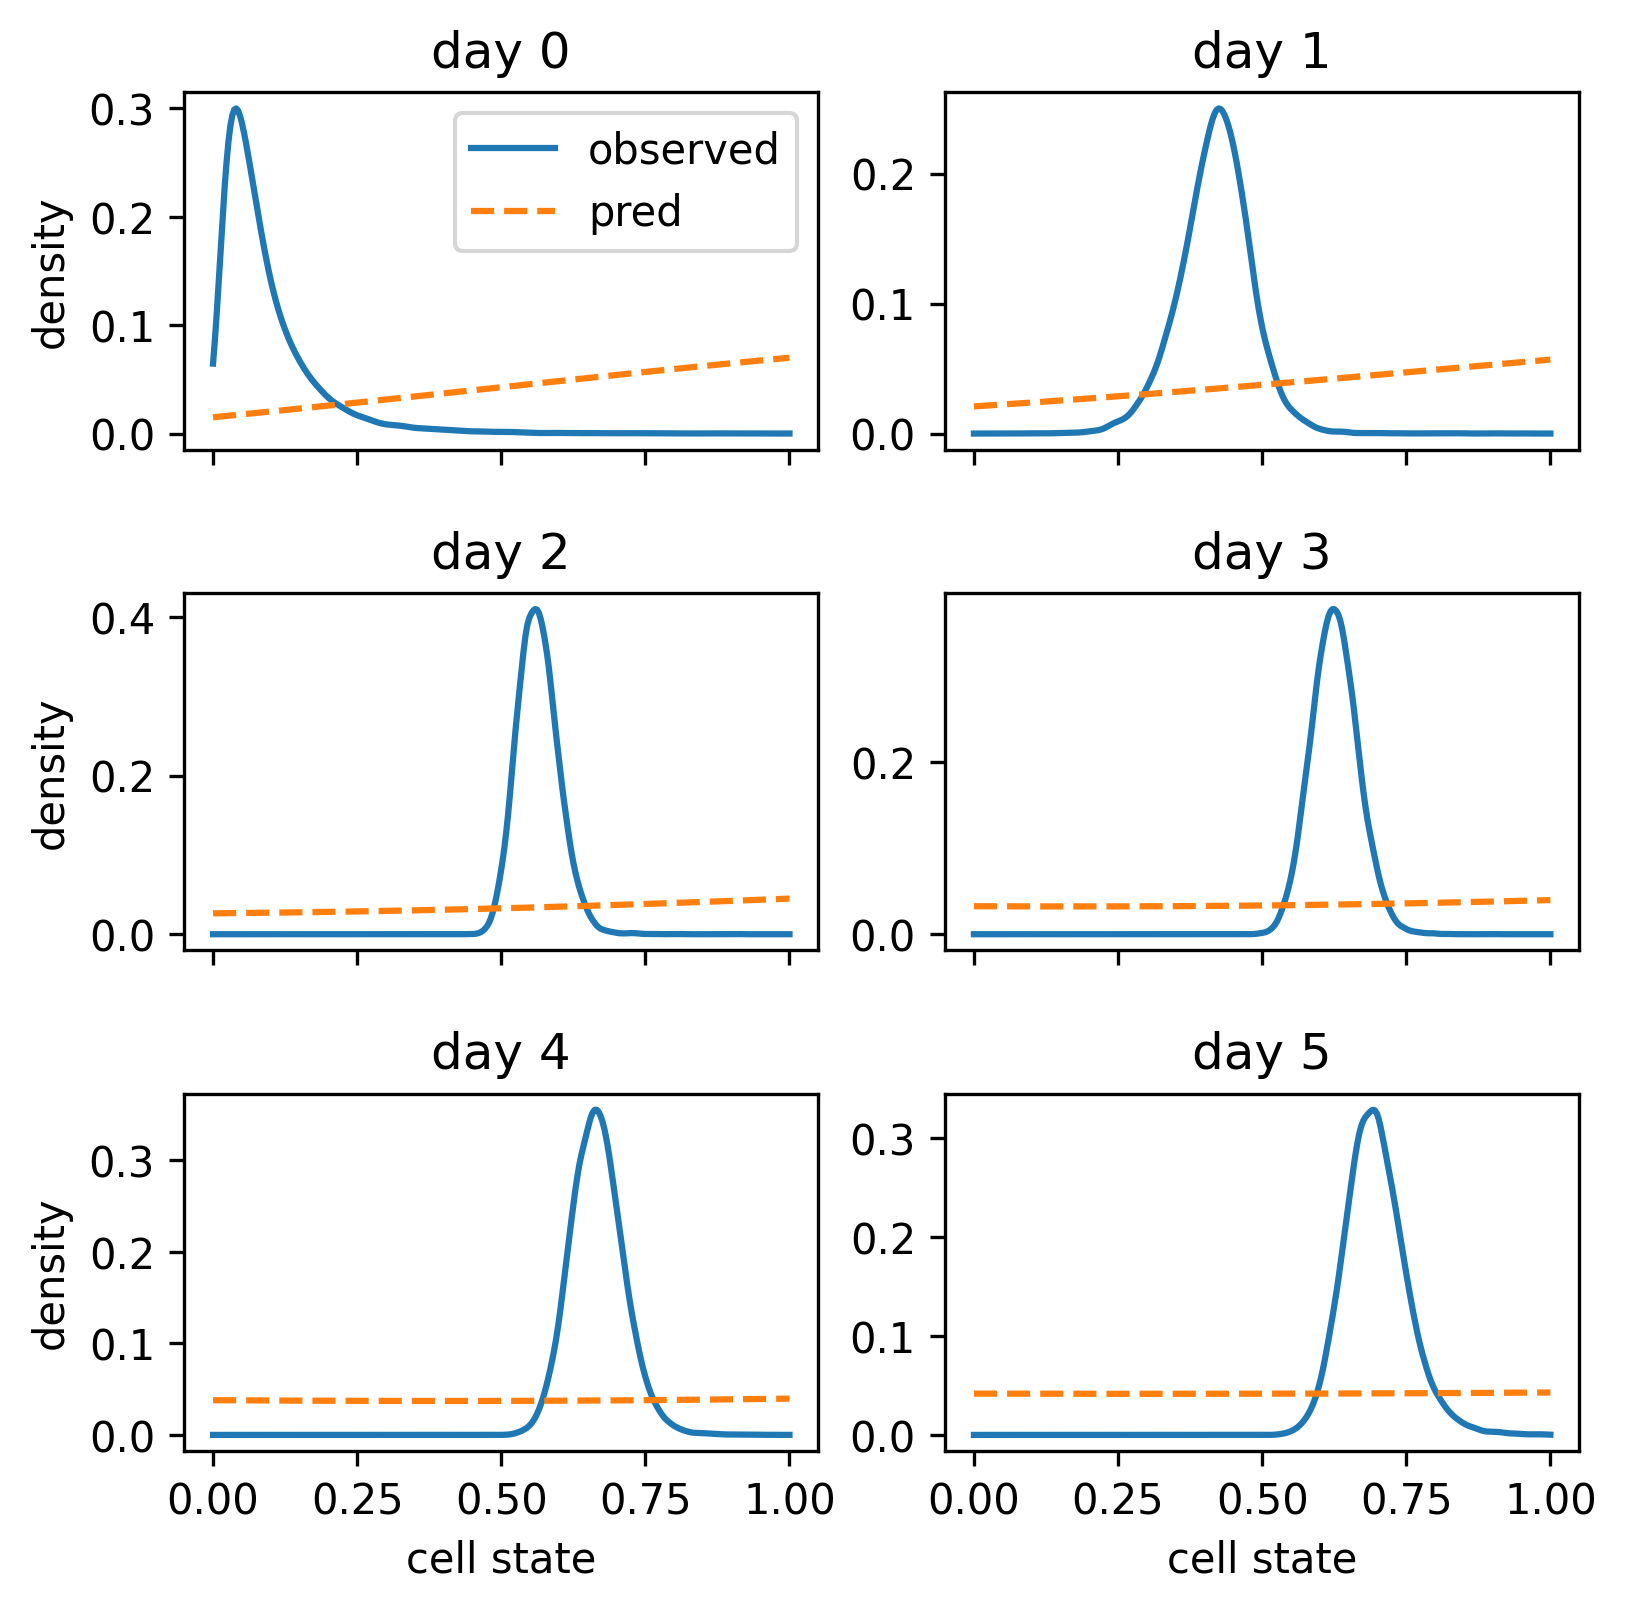

In [141]:
predict_and_vis(kld_m2, data_batch, train_DS)

# KLD from later

In [130]:
ckpt_path3 = "../logs/Cspline_PINN/lightning_logs/version_9/checkpoints/epoch=5-total_loss=208.62158203.ckpt"
kld_m3 = models.Cspline_PINN.load_from_checkpoint(ckpt_path3)

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


In [ ]:
kld_m3.

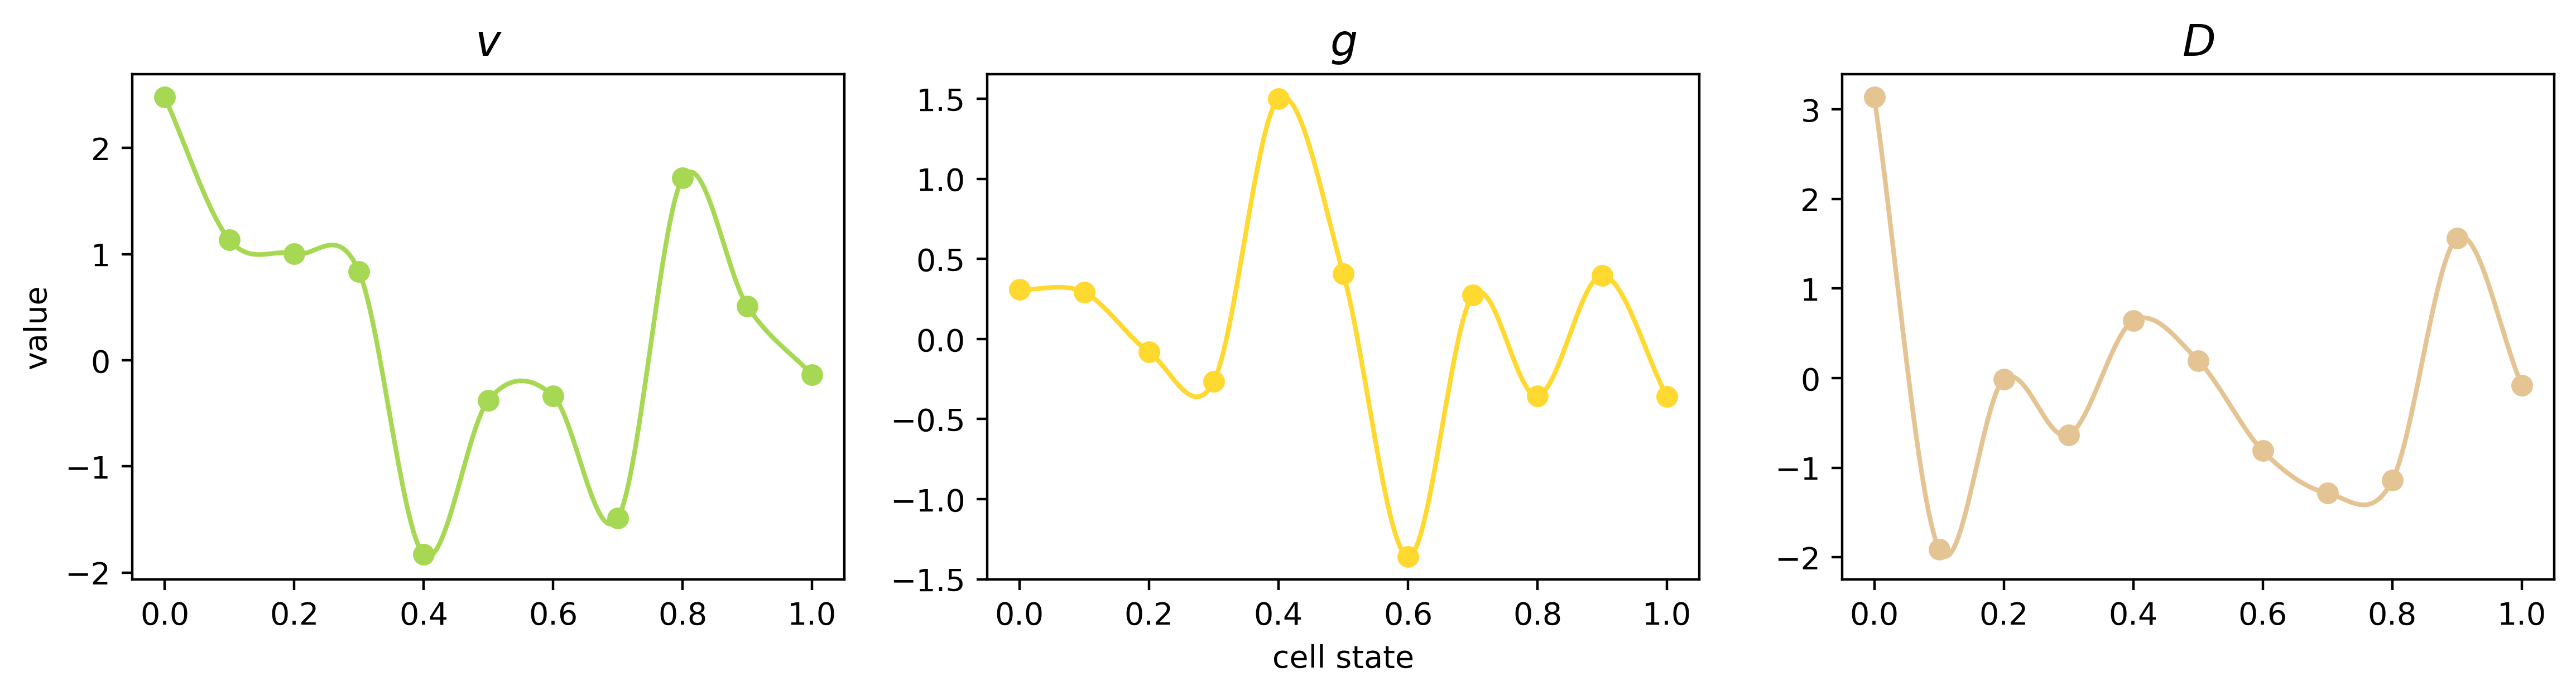

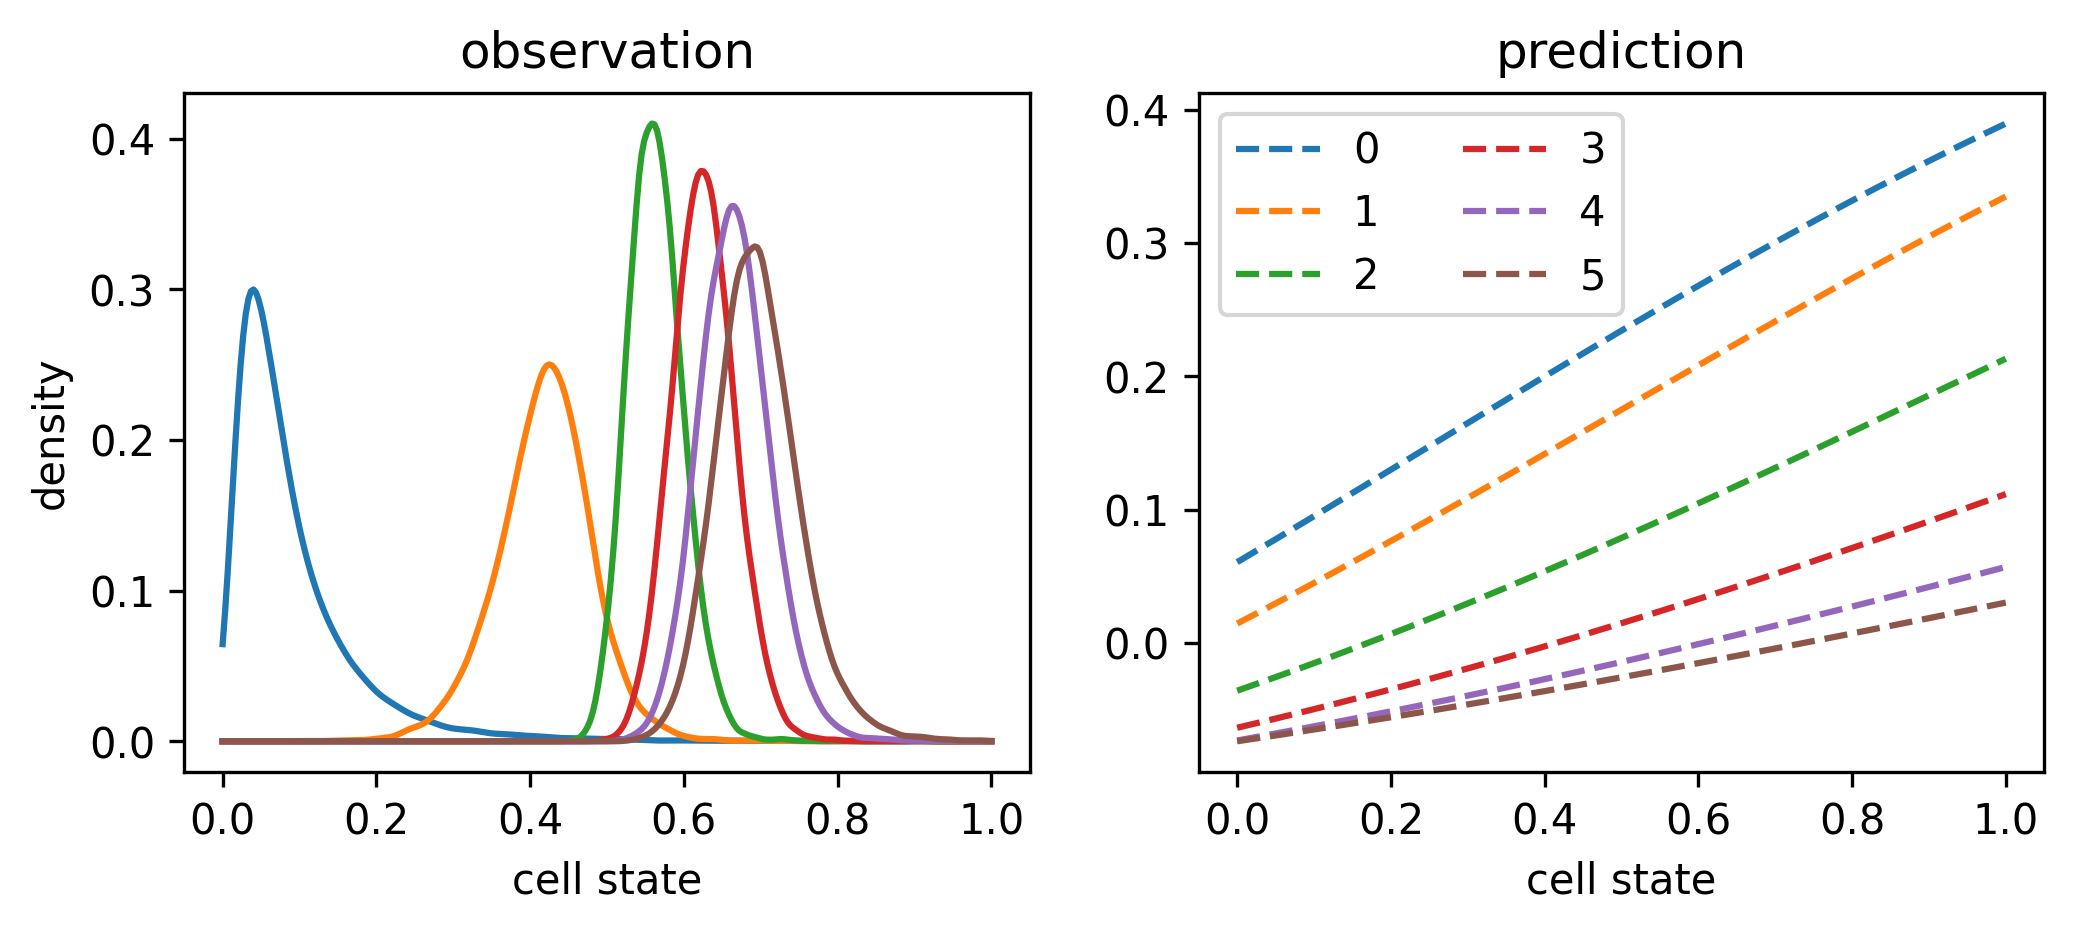

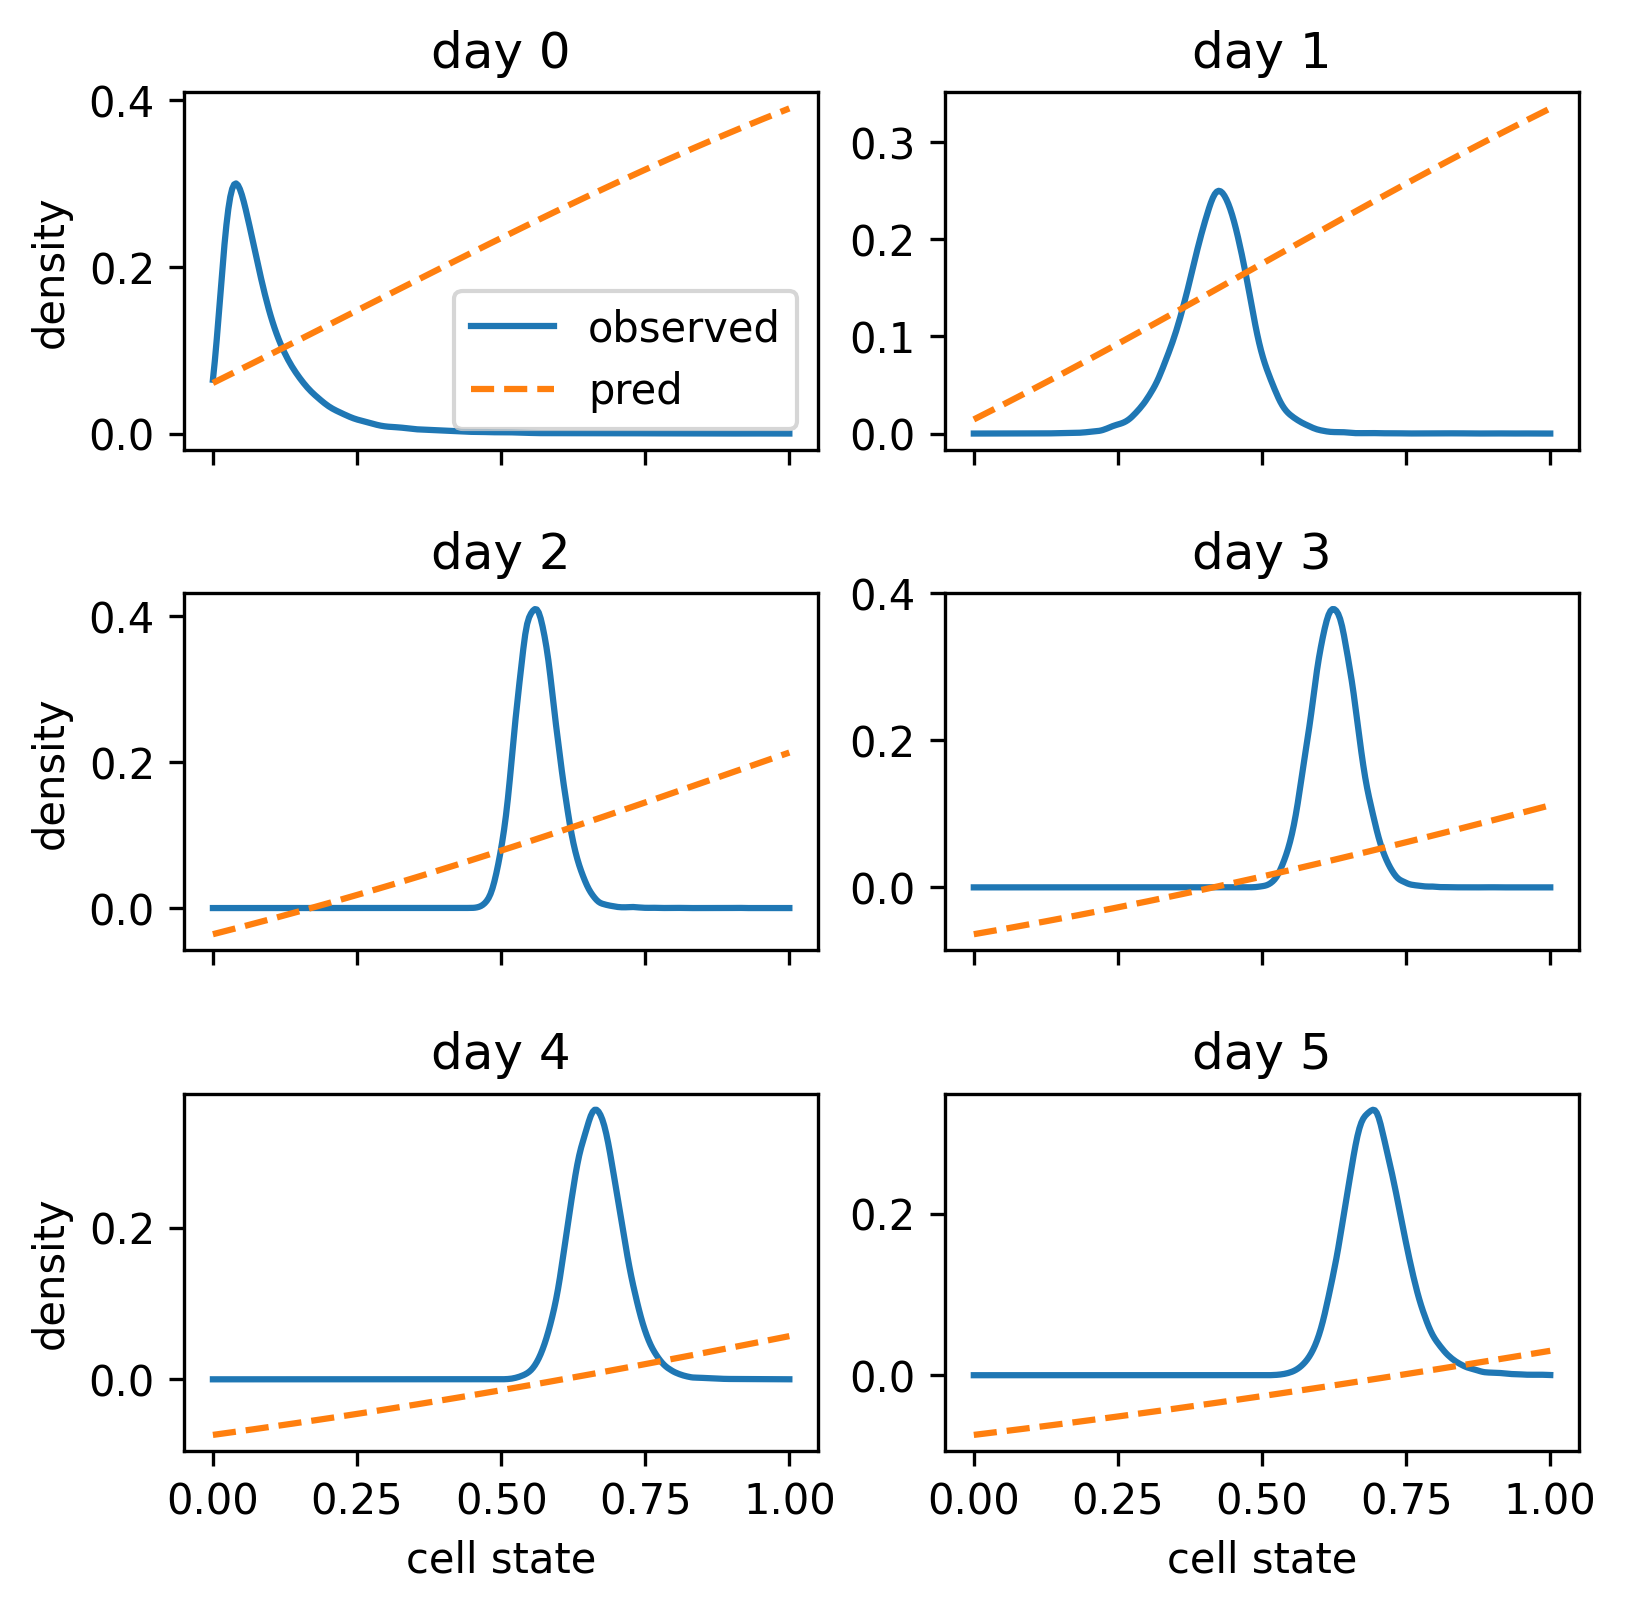

In [131]:
predict_and_vis(kld_m3, data_batch, train_DS)